# Statistics for Michel electron candidate

### Created by Shu, 20251101---

##### (20250916) Main update here is the introduction of CLASS, to upgrade current cumbersome data processing

#### To check ART Root Files

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Initial candidates:

In [1]:
from dataclasses import dataclass
import os

# ----------------------------- Dataclass ------------------------------------
@dataclass
class ParticleEvent:
    decayX_initial: float = None
    decayY_initial: float = None
    decayZ_initial: float = None
    startX_initial: float = None
    startY_initial: float = None
    startZ_initial: float = None
    MS_initial: float = None
    MH_initial: float = None
    energy_initial: float = None
    lifetime_initial: float = None
    pdg_initial: int = None
    eventID_initial: int = None
    trackID_initial: int = None


# ----------------------------- Helpers --------------------------------------
def read_values(file_path, cast_type=float):
    """Read a single file into a list."""
    values = []
    if not os.path.exists(file_path):
        print(f"[WARN] Missing file: {file_path}")
        return values
    with open(file_path, "r") as f:
        for line in f:
            val = line.strip()
            if val:
                try:
                    values.append(cast_type(val))
                except ValueError:
                    print(f"[WARN] Could not parse '{val}' in {file_path}")
    return values


def read_multiple(file_paths, cast_type=float):
    """Read multiple files and concatenate them."""
    combined = []
    for path in file_paths:
        combined.extend(read_values(path, cast_type))
    return combined


# ----------------------------- Configuration --------------------------------
data_groups = [
    {
        "data_dir": "./statResult_tpc",
        "dates": [
            "20251101"
        ]
    }
]

# map: class attribute -> (file prefix, value type)
fields_info = {
    "decayX_initial": ("decayX", float),
    "decayY_initial": ("decayY", float),
    "decayZ_initial": ("decayZ", float),
    "startX_initial": ("startX", float),
    "startY_initial": ("startY", float),
    "startZ_initial": ("startZ", float),
    "MS_initial": ("michelScore", float),
    "MH_initial": ("michelHits", float),
    "energy_initial": ("energy", float),
    "lifetime_initial": ("lifetime", float),
    "pdg_initial": ("pdg", int),
    "eventID_initial": ("eventID", int),
    "trackID_initial": ("trackID", int),
}

# ----------------------------- File Reading ---------------------------------
data = {k: [] for k in fields_info}  # initialize empty lists for each field

for group in data_groups:
    data_dir = group["data_dir"]
    dates_all = group["dates"]

    print(f"\n[INFO] Reading group: {data_dir}")
    for field, (stub, cast_type) in fields_info.items():

        for d in dates_all:
            file_path = f"{data_dir}/{stub}_New{d}_initial.txt"
            vals = read_values(file_path, cast_type)

            data[field].extend(vals)
            print(f"  - Loaded {len(vals):6d} entries from {d} → appended to {field}")

print("\n[INFO] Combined totals:")
for field in data:
    print(f"  {field}: {len(data[field])} entries")


# ----------------------------- Build Events ---------------------------------
n_events = len(next(iter(data.values())))
events_reco = [
    ParticleEvent(**{k: data[k][i] for k in data})
    for i in range(n_events)
]

print(f"\n[OK] Created {len(events_reco)} ParticleEvent objects.")


print("Candidates ( MH > xxx): ", len(events_reco))

print("\nExample: ")
print(events_reco[0].decayX_initial)
print(events_reco[0].energy_initial)
print(events_reco[0].pdg_initial)




# ----------------------------- Create Lists for Direct Access ----------------
# Create standalone lists (just like your old style)
decayX_initial   = data["decayX_initial"]
decayY_initial   = data["decayY_initial"]
decayZ_initial   = data["decayZ_initial"]
startX_initial   = data["startX_initial"]
startY_initial   = data["startY_initial"]
startZ_initial   = data["startZ_initial"]
MS_initial       = data["MS_initial"]
MH_initial       = data["MH_initial"]
energy_initial   = data["energy_initial"]
lifetime_initial = data["lifetime_initial"]
pdg_initial      = data["pdg_initial"]
eventID_initial  = data["eventID_initial"]
trackID_initial  = data["trackID_initial"]





#True Michel events----------
events_true = []
trueE_num = 0
trueL_num = 0
for ev in events_reco:
    if ev.energy_initial > 0:
        trueE_num += 1
        events_true.append(ev)
    if ev.lifetime_initial > 0:
        trueL_num += 1

print("\n# of True events: ", len(events_true))
print("Events with E > 0 (true Michel): ", trueE_num, "({:.2f}%)".format(trueE_num/len(events_reco)*100))
print("Events with L > 0 (true Michel): ", trueL_num, "({:.2f}%)".format(trueL_num/len(events_reco)*100))




[INFO] Reading group: ./statResult_tpc
  - Loaded   4252 entries from 20251101 → appended to decayX_initial
  - Loaded   4252 entries from 20251101 → appended to decayY_initial
  - Loaded   4252 entries from 20251101 → appended to decayZ_initial
  - Loaded   4252 entries from 20251101 → appended to startX_initial
  - Loaded   4252 entries from 20251101 → appended to startY_initial
  - Loaded   4252 entries from 20251101 → appended to startZ_initial
  - Loaded   4252 entries from 20251101 → appended to MS_initial
  - Loaded   4252 entries from 20251101 → appended to MH_initial
  - Loaded   4252 entries from 20251101 → appended to energy_initial
  - Loaded   4252 entries from 20251101 → appended to lifetime_initial
  - Loaded   4252 entries from 20251101 → appended to pdg_initial
  - Loaded   4252 entries from 20251101 → appended to eventID_initial
  - Loaded   4252 entries from 20251101 → appended to trackID_initial

[INFO] Combined totals:
  decayX_initial: 4252 entries
  decayY_initi


Decay points distribution: 
# of X < 0 :  1928 (45.34%)
# of X >= 0:  2324 (54.66%)


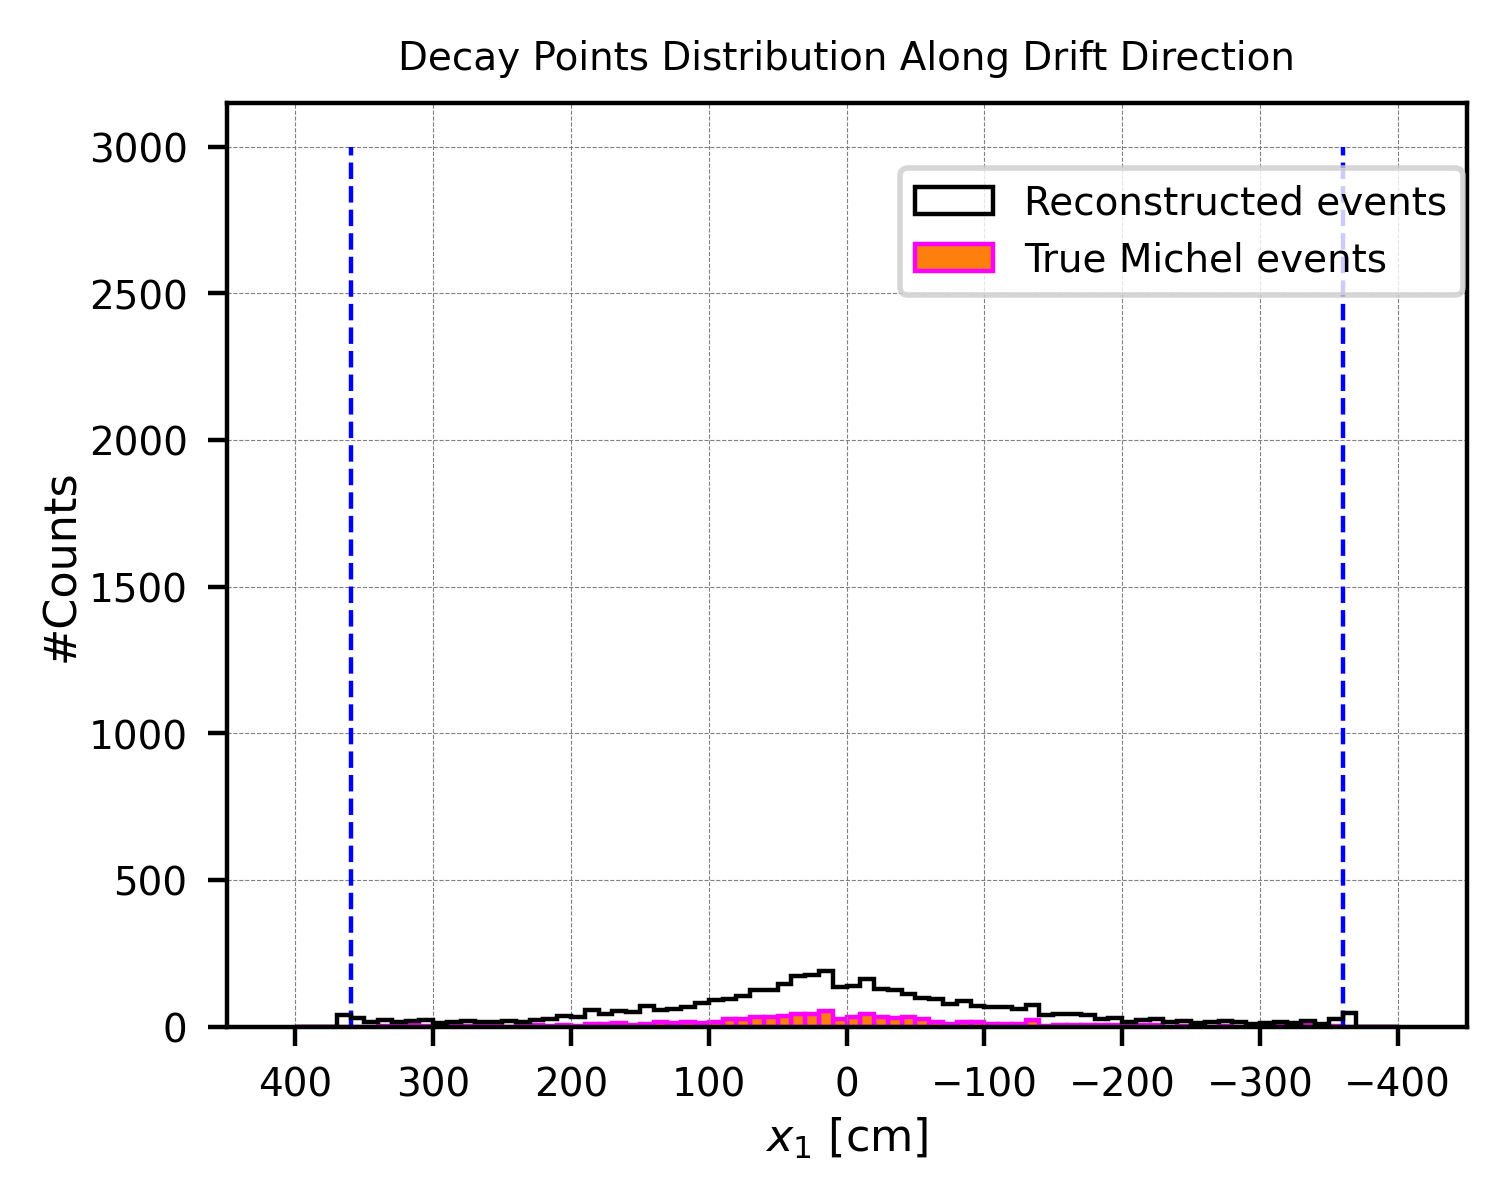

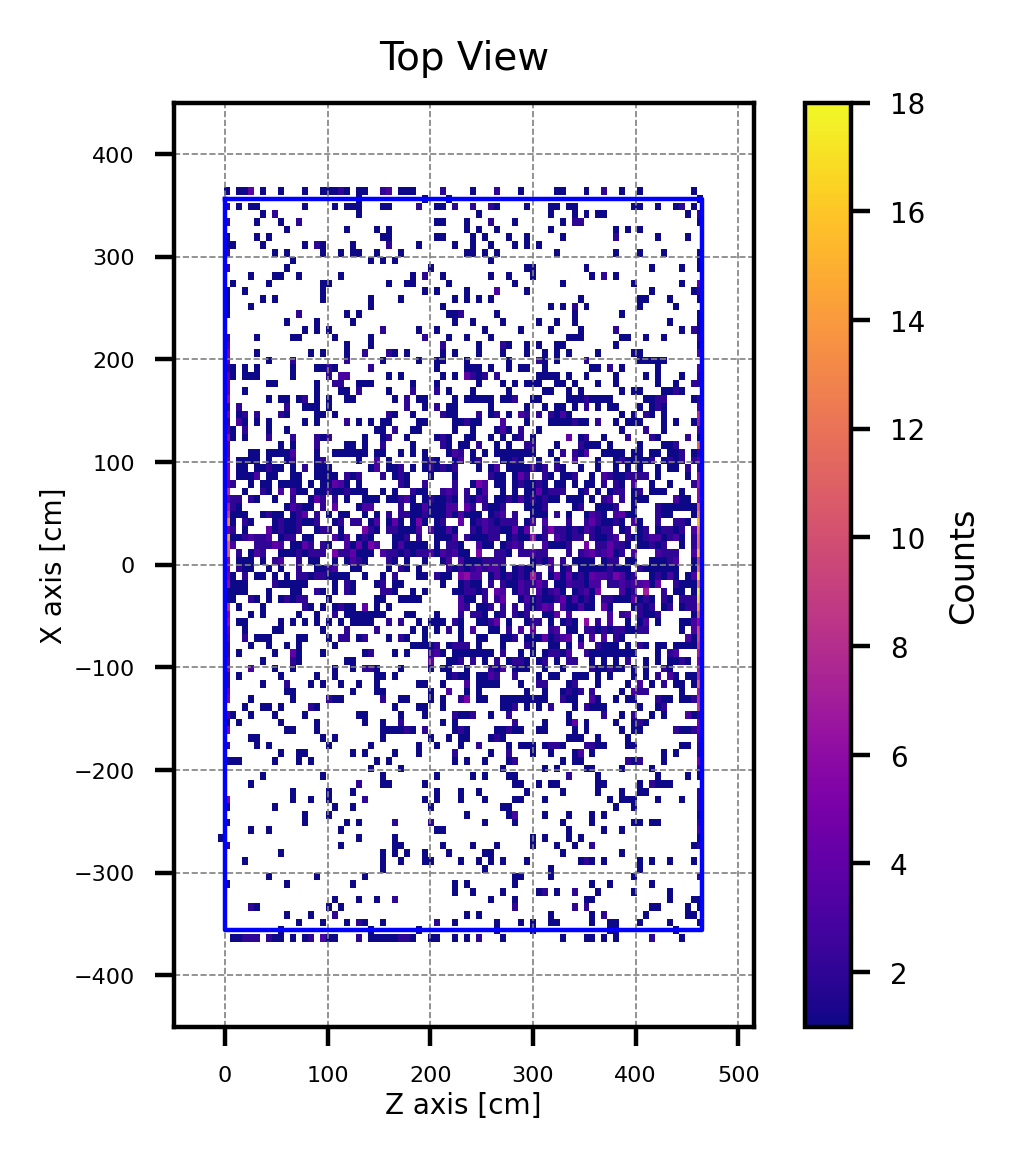

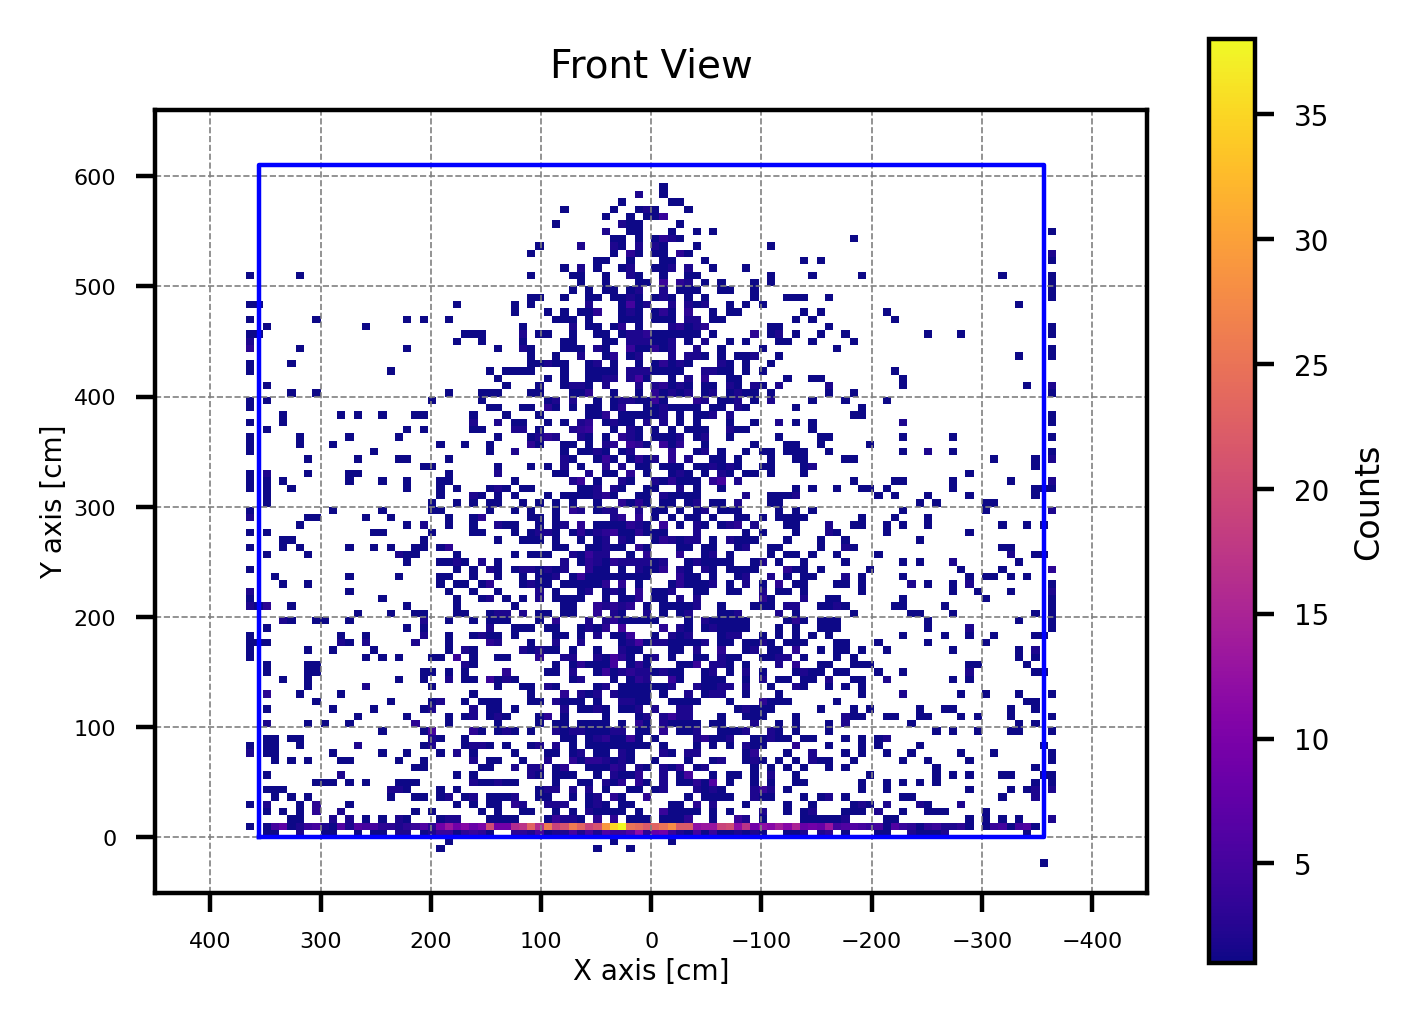

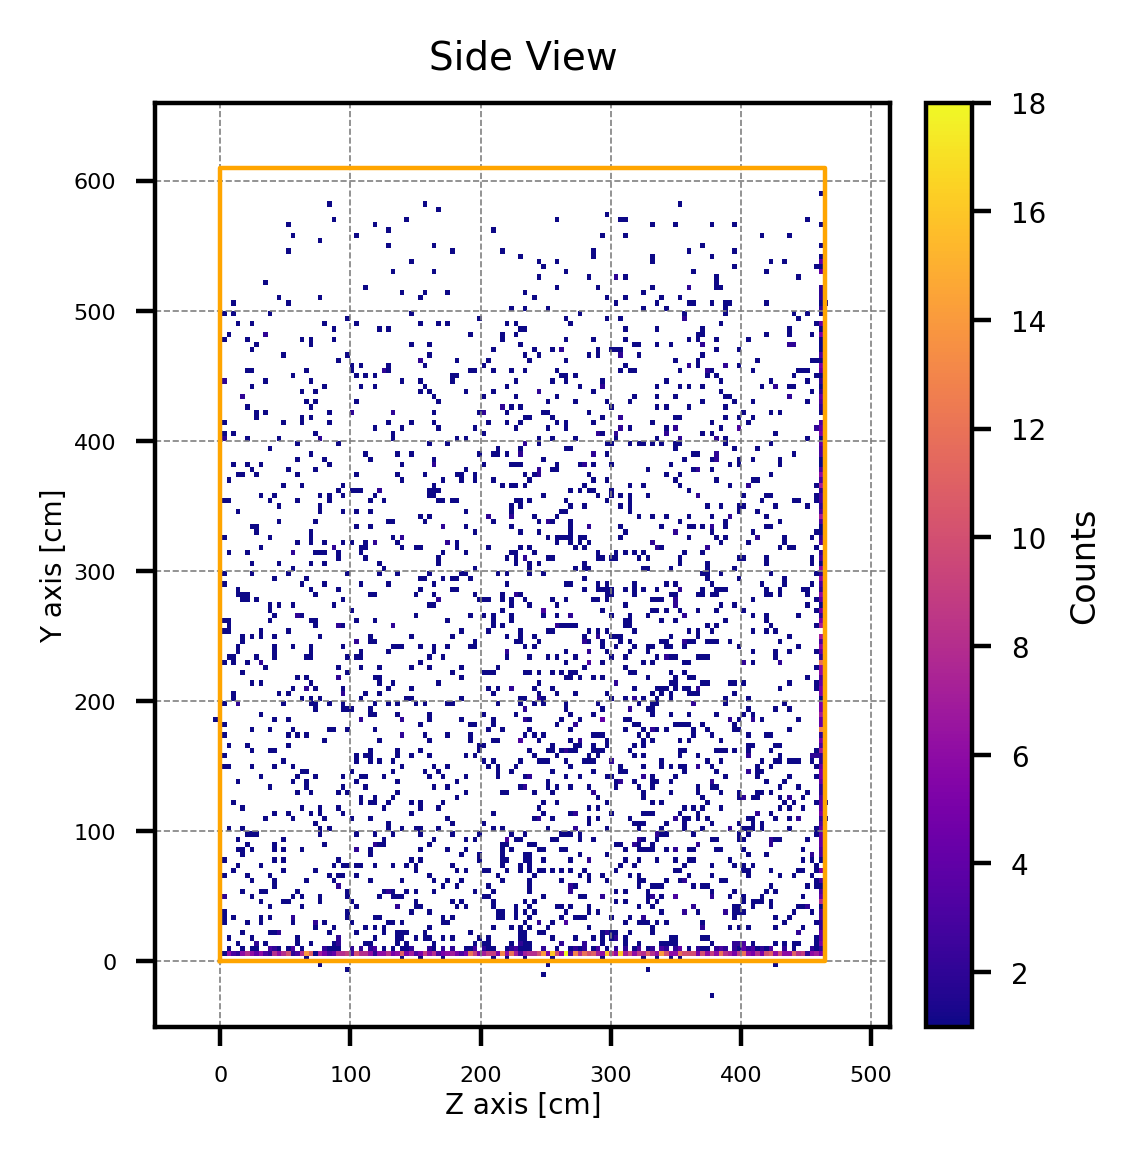


min(vals_MS_initial) 0.0100099
MS>0.1:  2049


<Figure size 1600x1200 with 0 Axes>

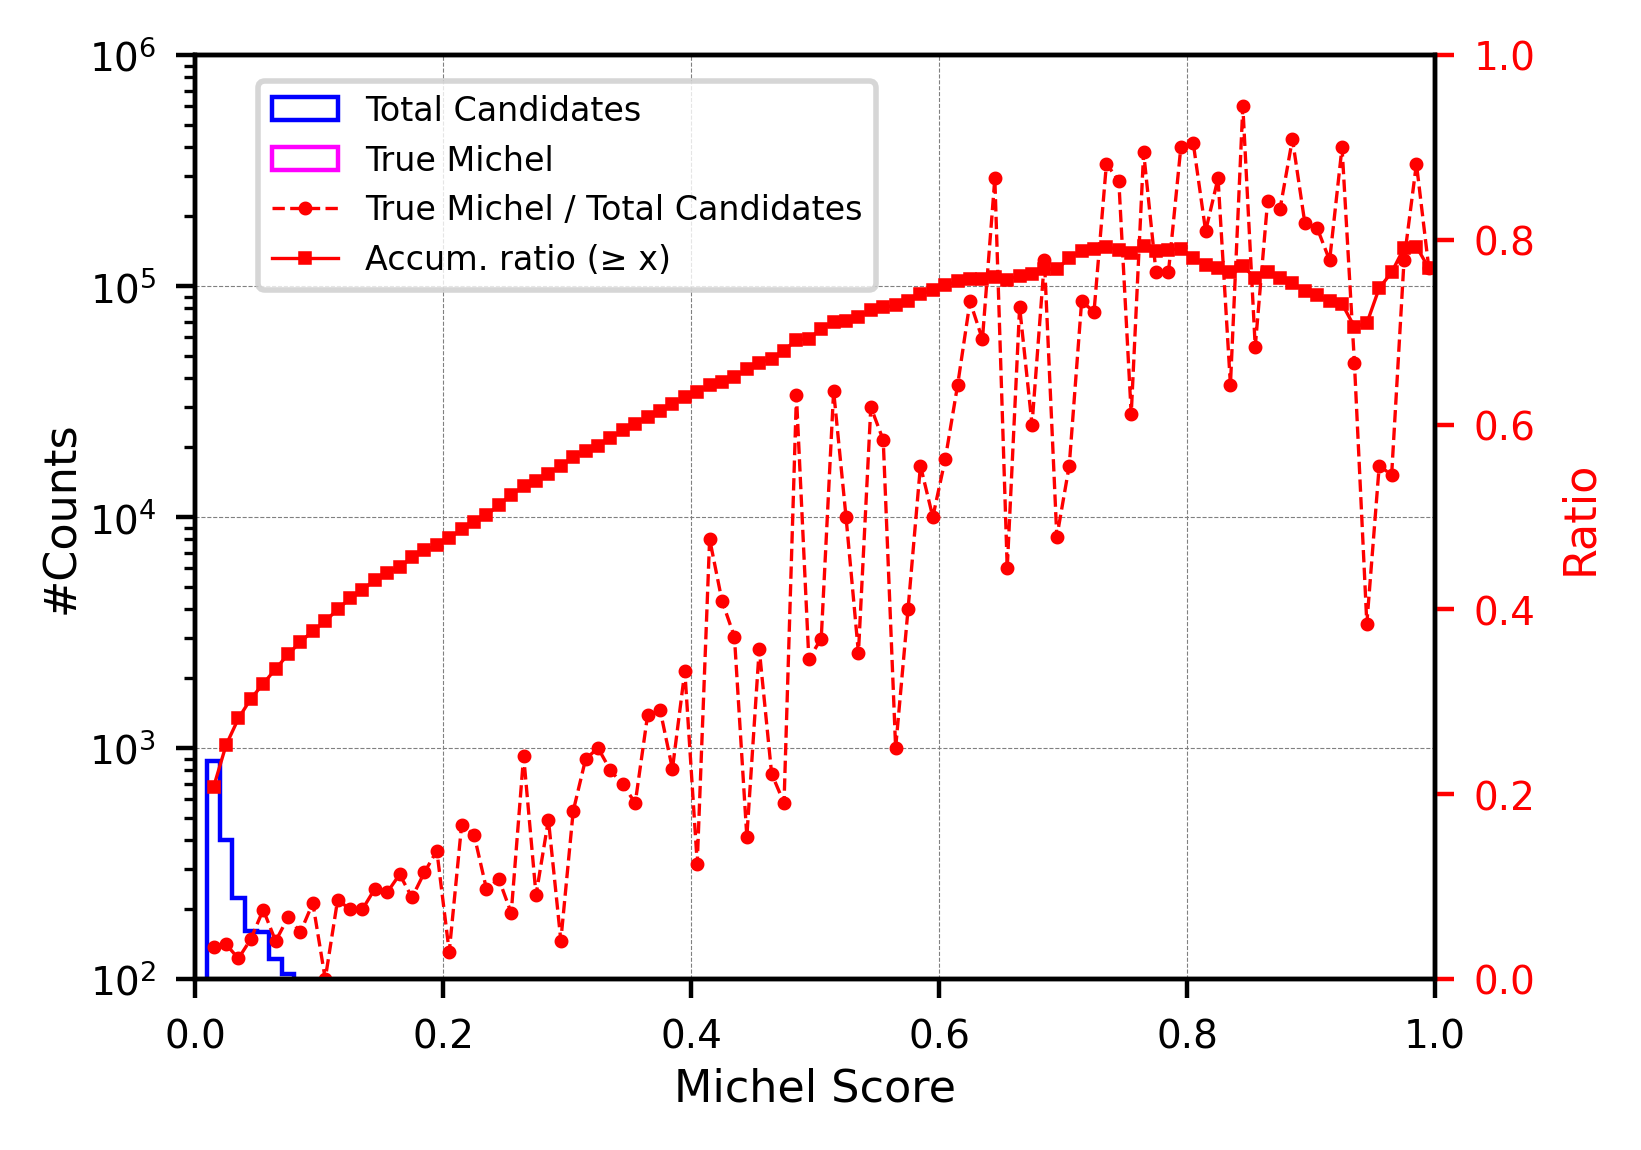

<Figure size 1600x1200 with 0 Axes>

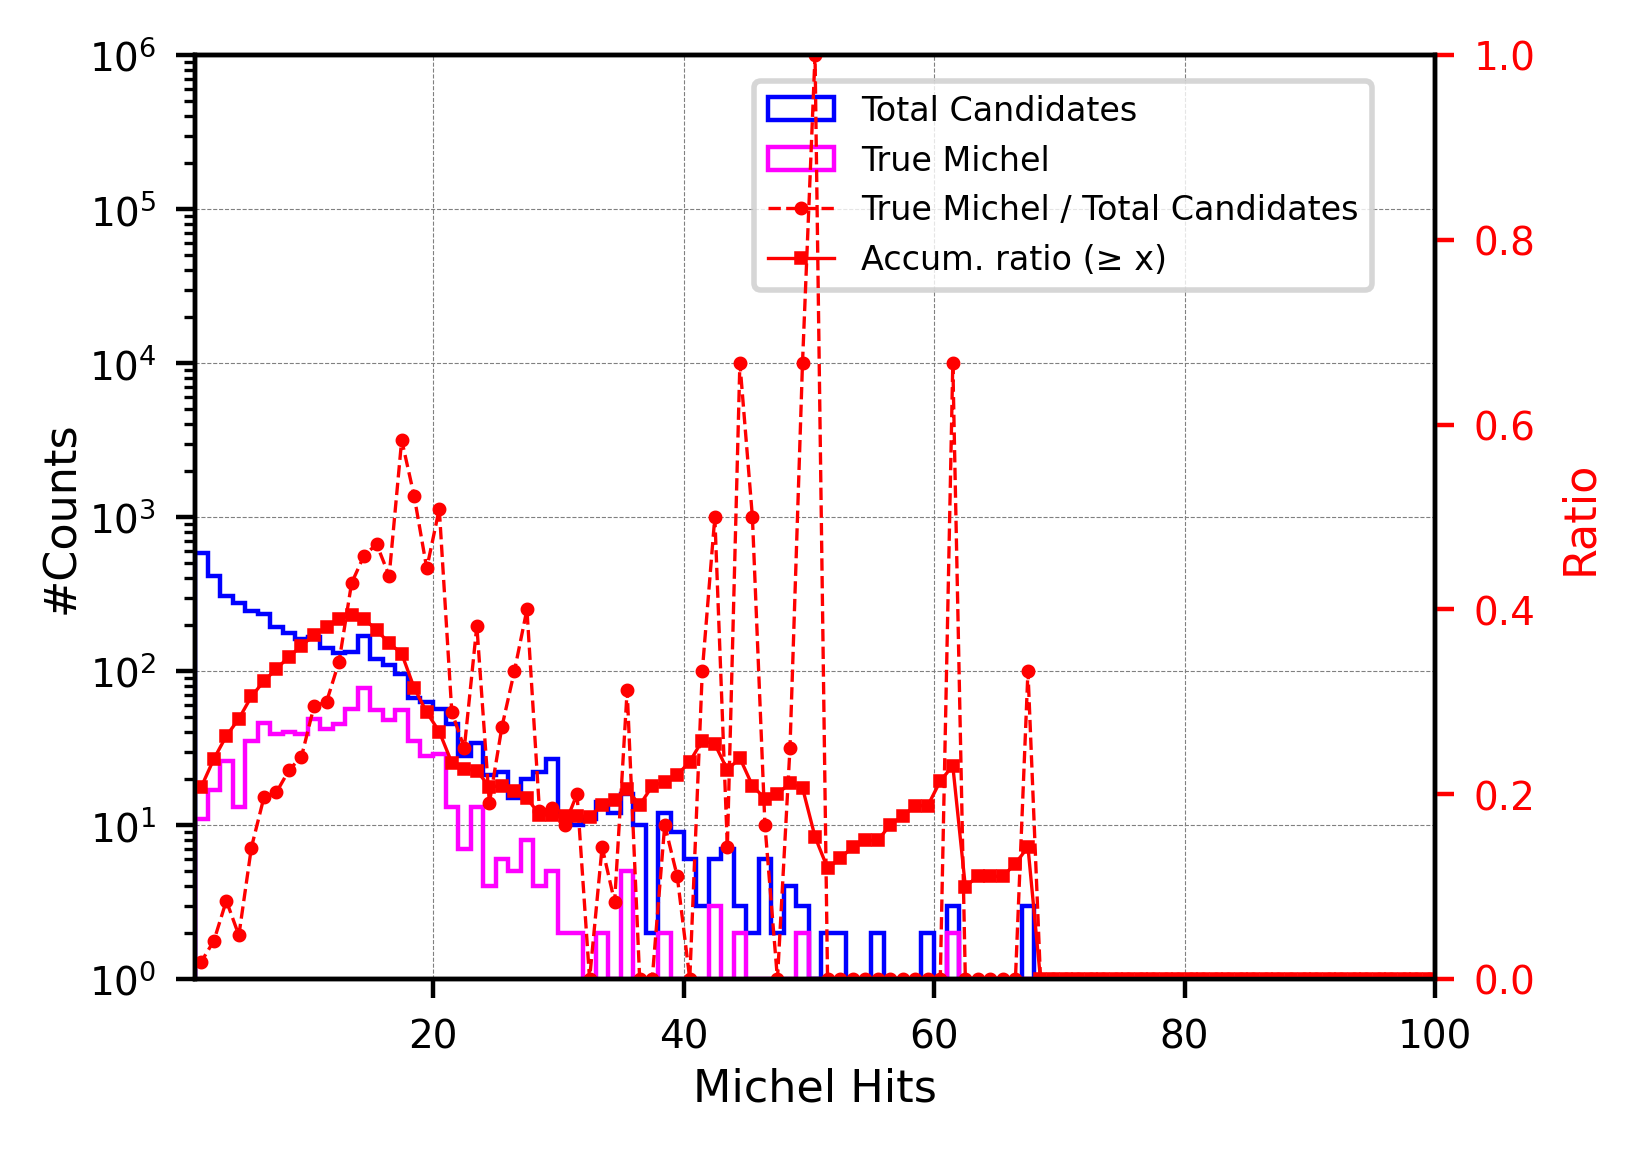

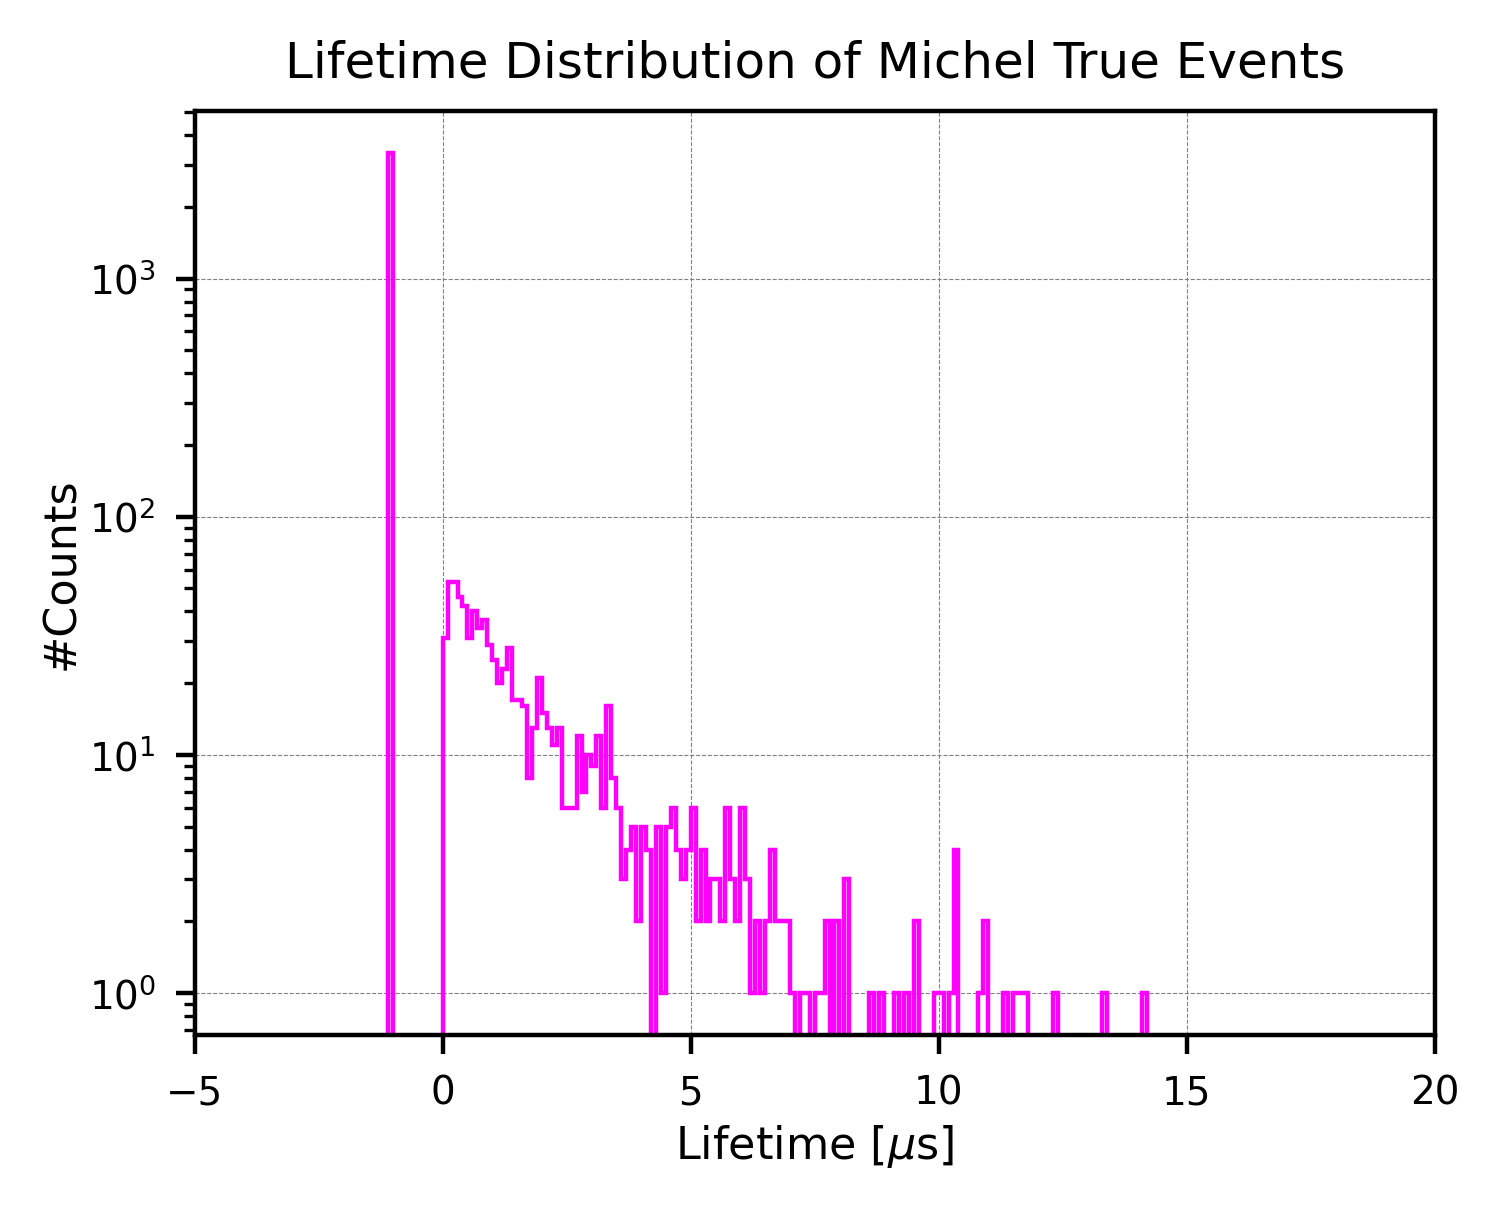

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in events_reco]
vals_decayY_initial = [ev.decayY_initial for ev in events_reco]
vals_decayZ_initial = [ev.decayZ_initial for ev in events_reco]
vals_MS_initial = [ev.MS_initial for ev in events_reco]
vals_MH_initial = [ev.MH_initial for ev in events_reco]
vals_lifetime_initial = [ev.lifetime_initial for ev in events_reco]

vals_decayX_true = [ev.decayX_initial for ev in events_true]
vals_MS_true = [ev.MS_initial for ev in events_true]
vals_MH_true = [ev.MH_initial for ev in events_true]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(vals_decayX_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 30000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(200, 200), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

print("\n==========================")
print("min(vals_MS_initial)", min(vals_MS_initial))
count = sum(1 for x in vals_MS_initial if x > 0.1)
print("MS>0.1: ", count)



# Define the range and bin width
bin_width = 0.01
range_min = 0.01 #====================Remember to recover back---
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MS_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([0.5, 0.5], [0, 100000], color="green", linewidth=1.2, linestyle='--')

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(0.0, 1.0) #(-0.02, 1.02)
ax1.set_ylim(100, 1000000)
plt.yscale('log')
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")


# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0, 1.00)
ax2.tick_params(axis='y', labelsize=7, colors='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})


plt.show()








#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MH_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([8, 8], [0, 300000], color="green", linewidth=1.2, linestyle='--')


# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_ylim(1, 1000000)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
plt.yscale('log')
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ax2.set_ylim(0, 1.0)
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")



# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})

plt.show() 








#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_lifetime_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()









<br />
<br />
<br />

## Explore True Michel distribution:

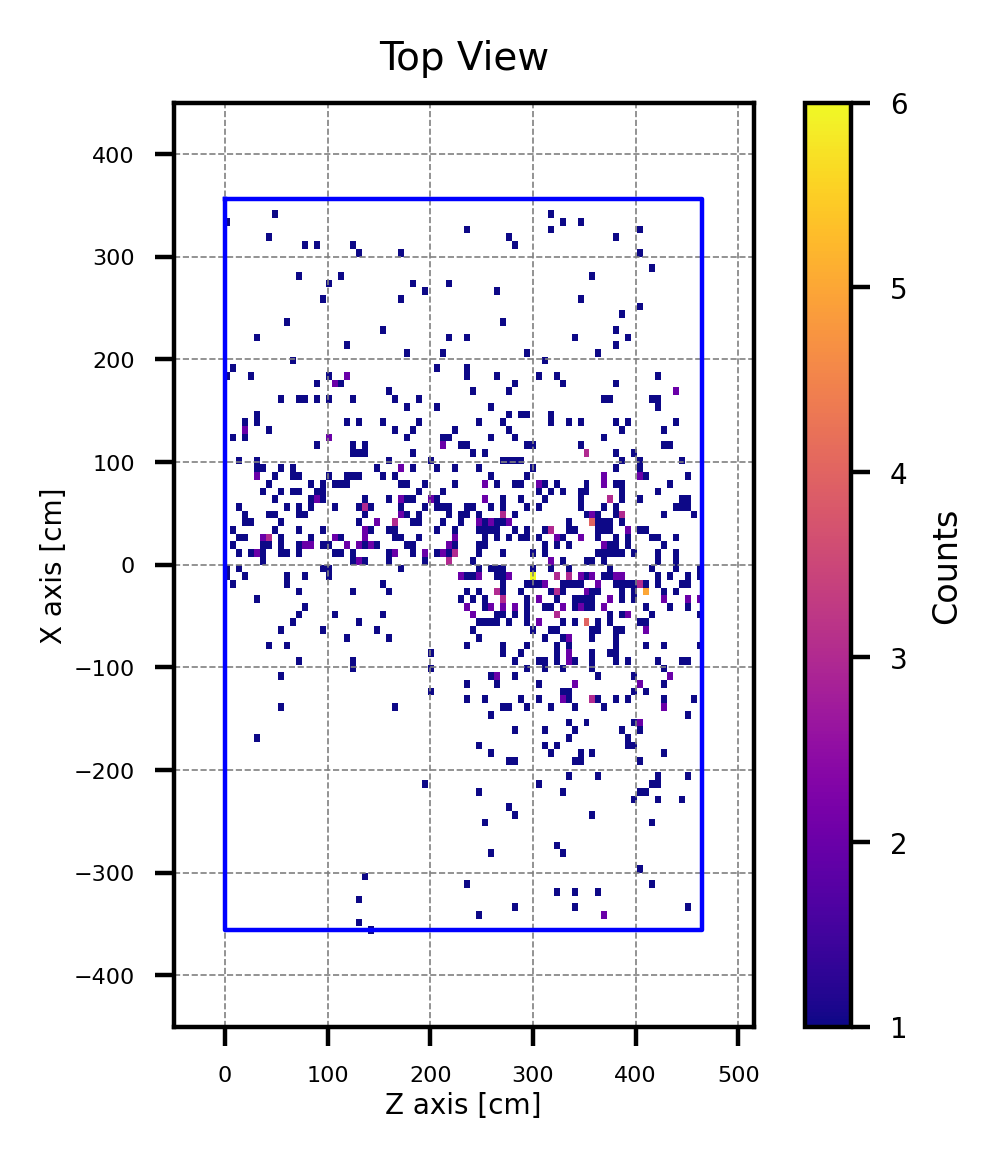

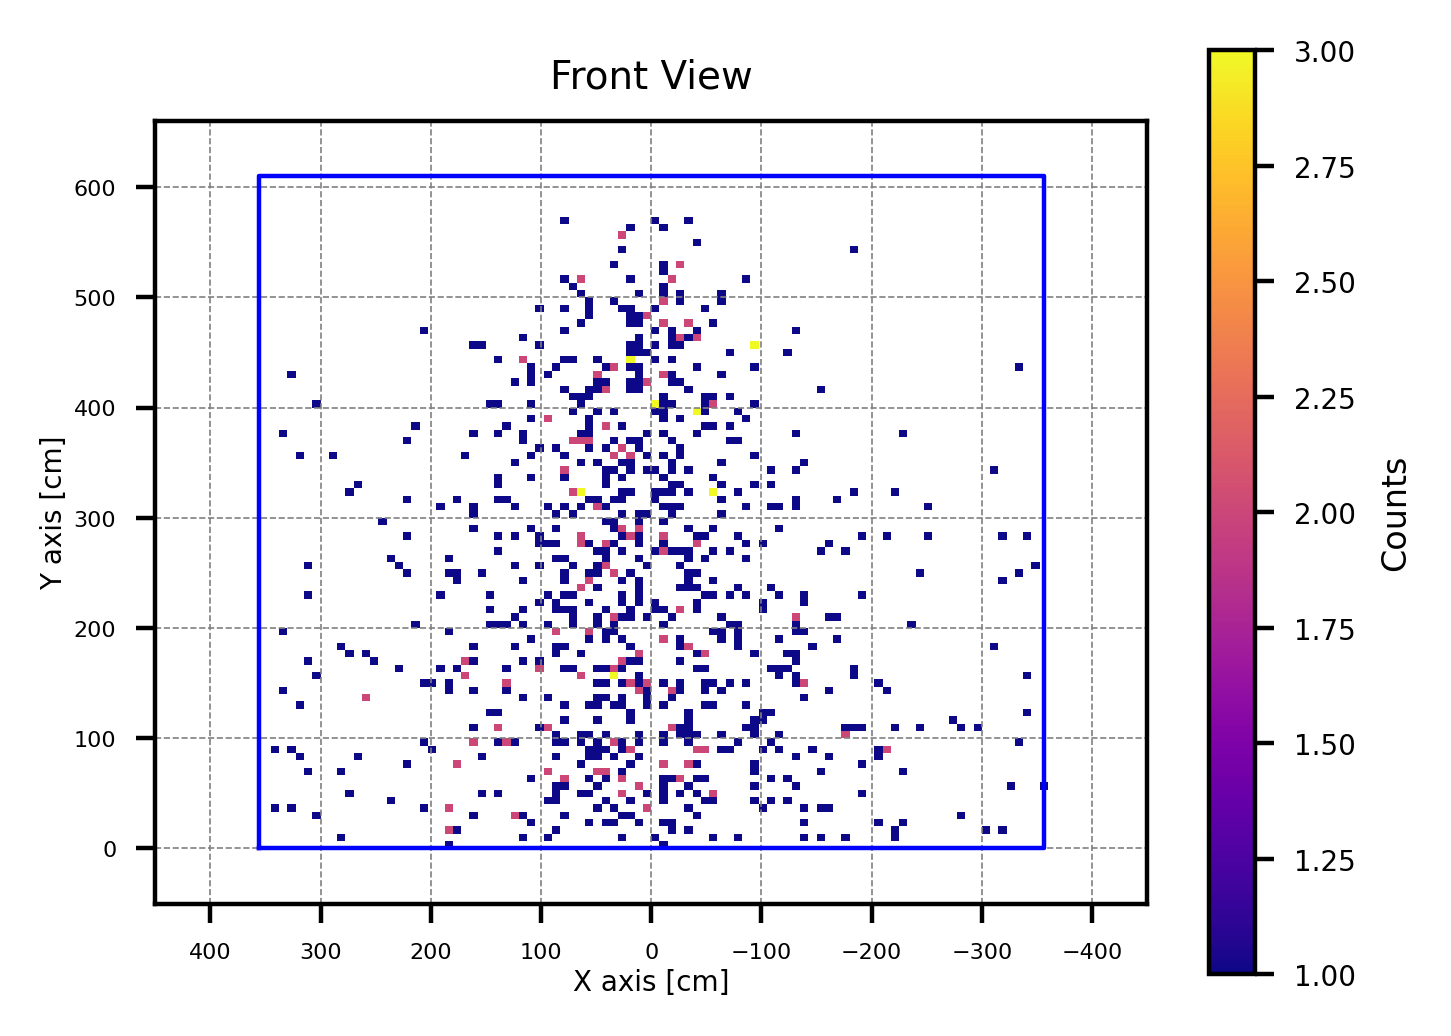

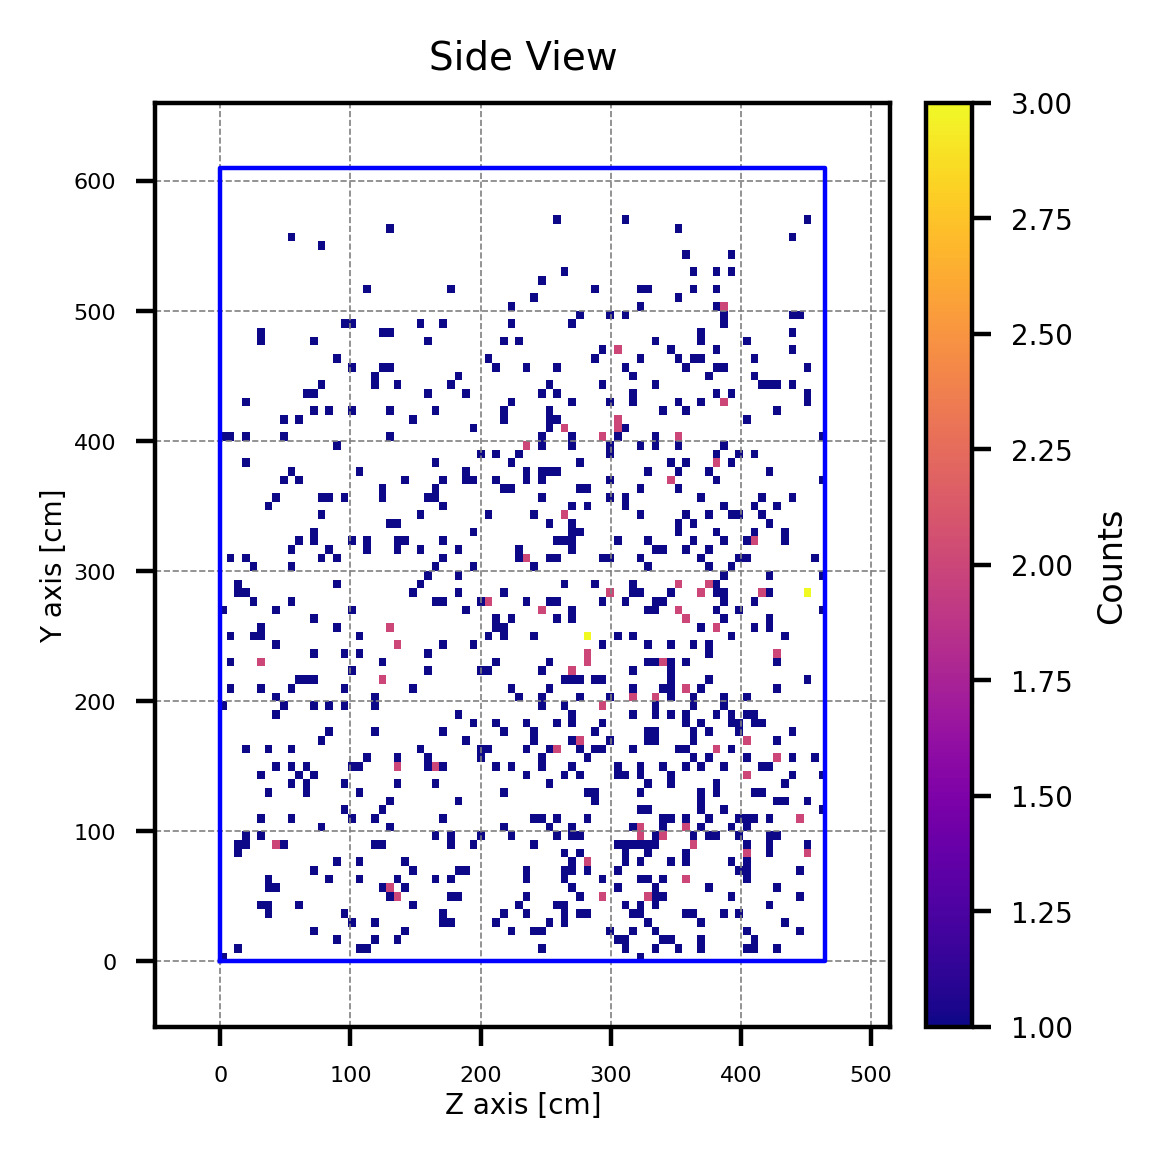

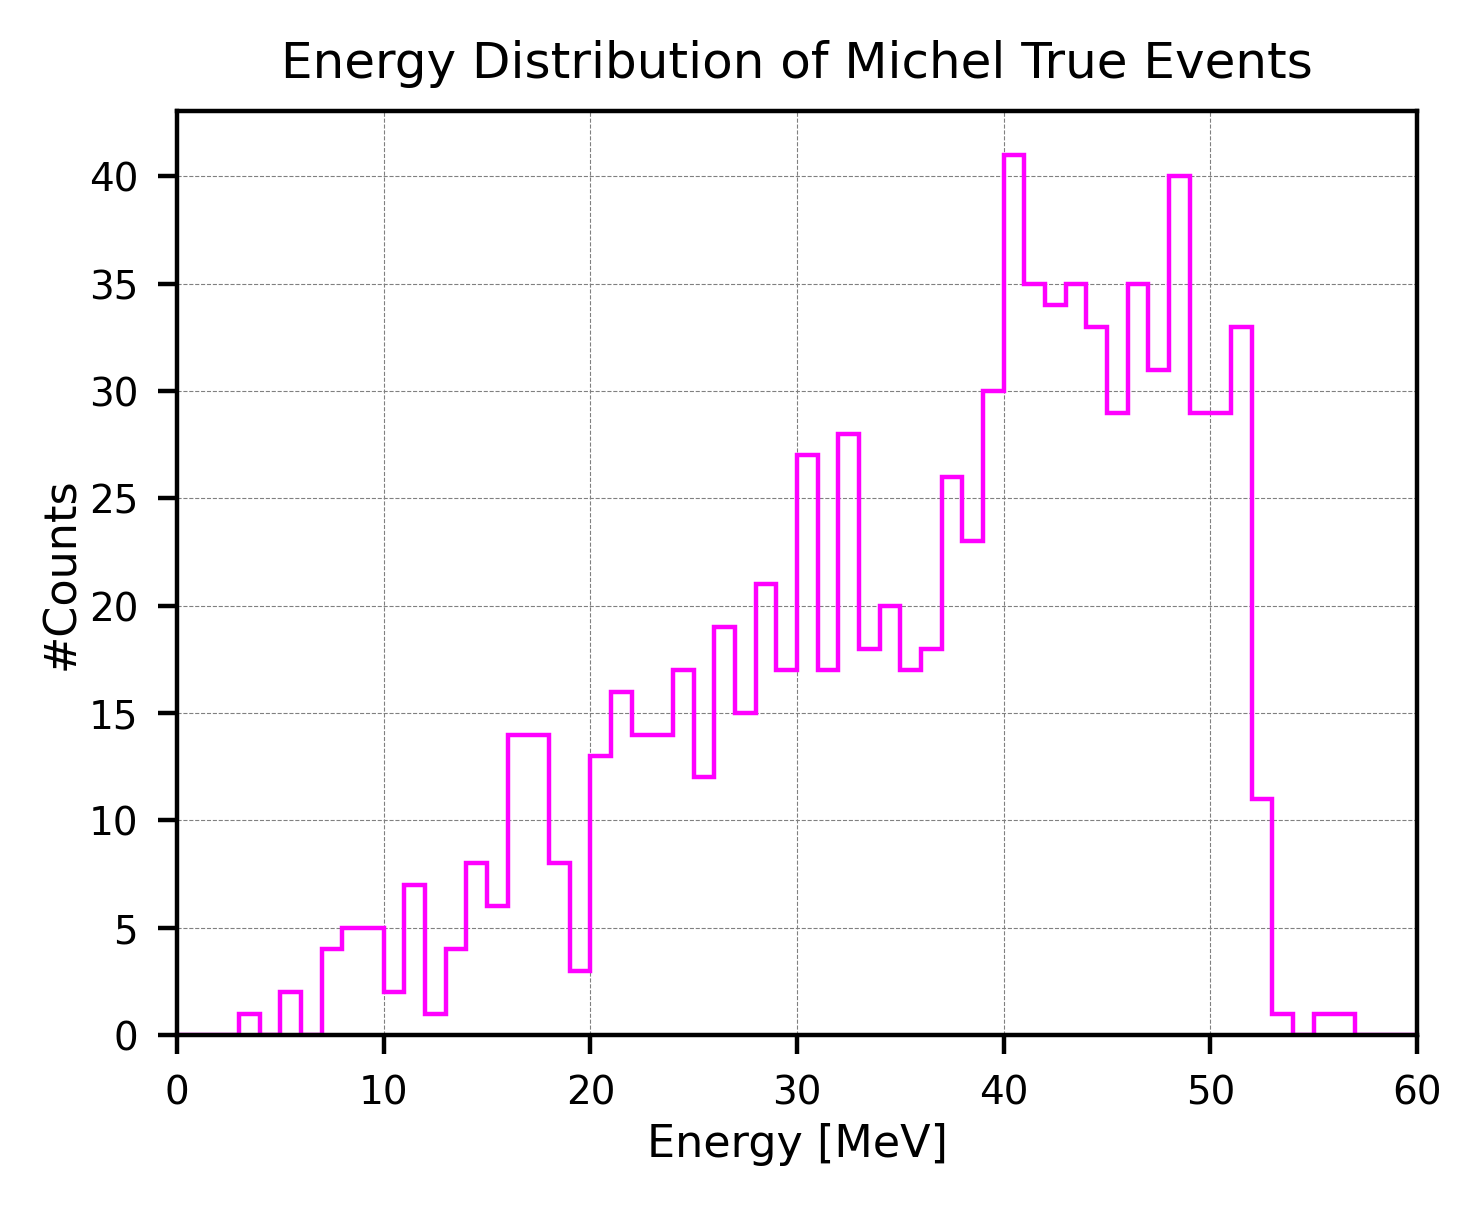

In [3]:
 
vals_decayY_true = [ev.decayY_initial for ev in events_true]
vals_decayZ_true = [ev.decayZ_initial for ev in events_true]
vals_energy_true = [ev.energy_initial for ev in events_true]


#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_true, vals_decayX_true, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_true, vals_decayY_true, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_true, vals_decayY_true, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 







#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_energy_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(0, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  




<br />
<br />
<br />
<br />

## e^+ and e^- quick separation:

In [4]:
import math


# Seperate Michel e^- and e^+------------------------------
life_pM = []
life_nM = []
count_0= 0

events_pM = []#e^+---
events_nM = []

for i in range(0, len(events_true)):
    pdg = events_true[i].pdg_initial
    life = events_true[i].lifetime_initial

    if pdg < 0:
        life_pM.append(life)
        events_pM.append(events_true[i])

    elif pdg > 0:
        life_nM.append(life)
        events_nM.append(events_true[i])



print("\nMichel e^+: ", len(life_pM), "/", len(events_true), "({:.2f}%)".format(len(life_pM)/len(events_true)*100))
print("Michel e^-: ", len(life_nM), "/", len(events_true), "({:.2f}%)".format(len(life_nM)/len(events_true)*100))

print("\n#e^+ / #e^-: ", len(life_pM), "/", len(life_nM), 
      "({:.2f})".format(len(life_pM)/len(life_nM)))




Michel e^+:  734 / 884 (83.03%)
Michel e^-:  150 / 884 (16.97%)

#e^+ / #e^-:  734 / 150 (4.89)


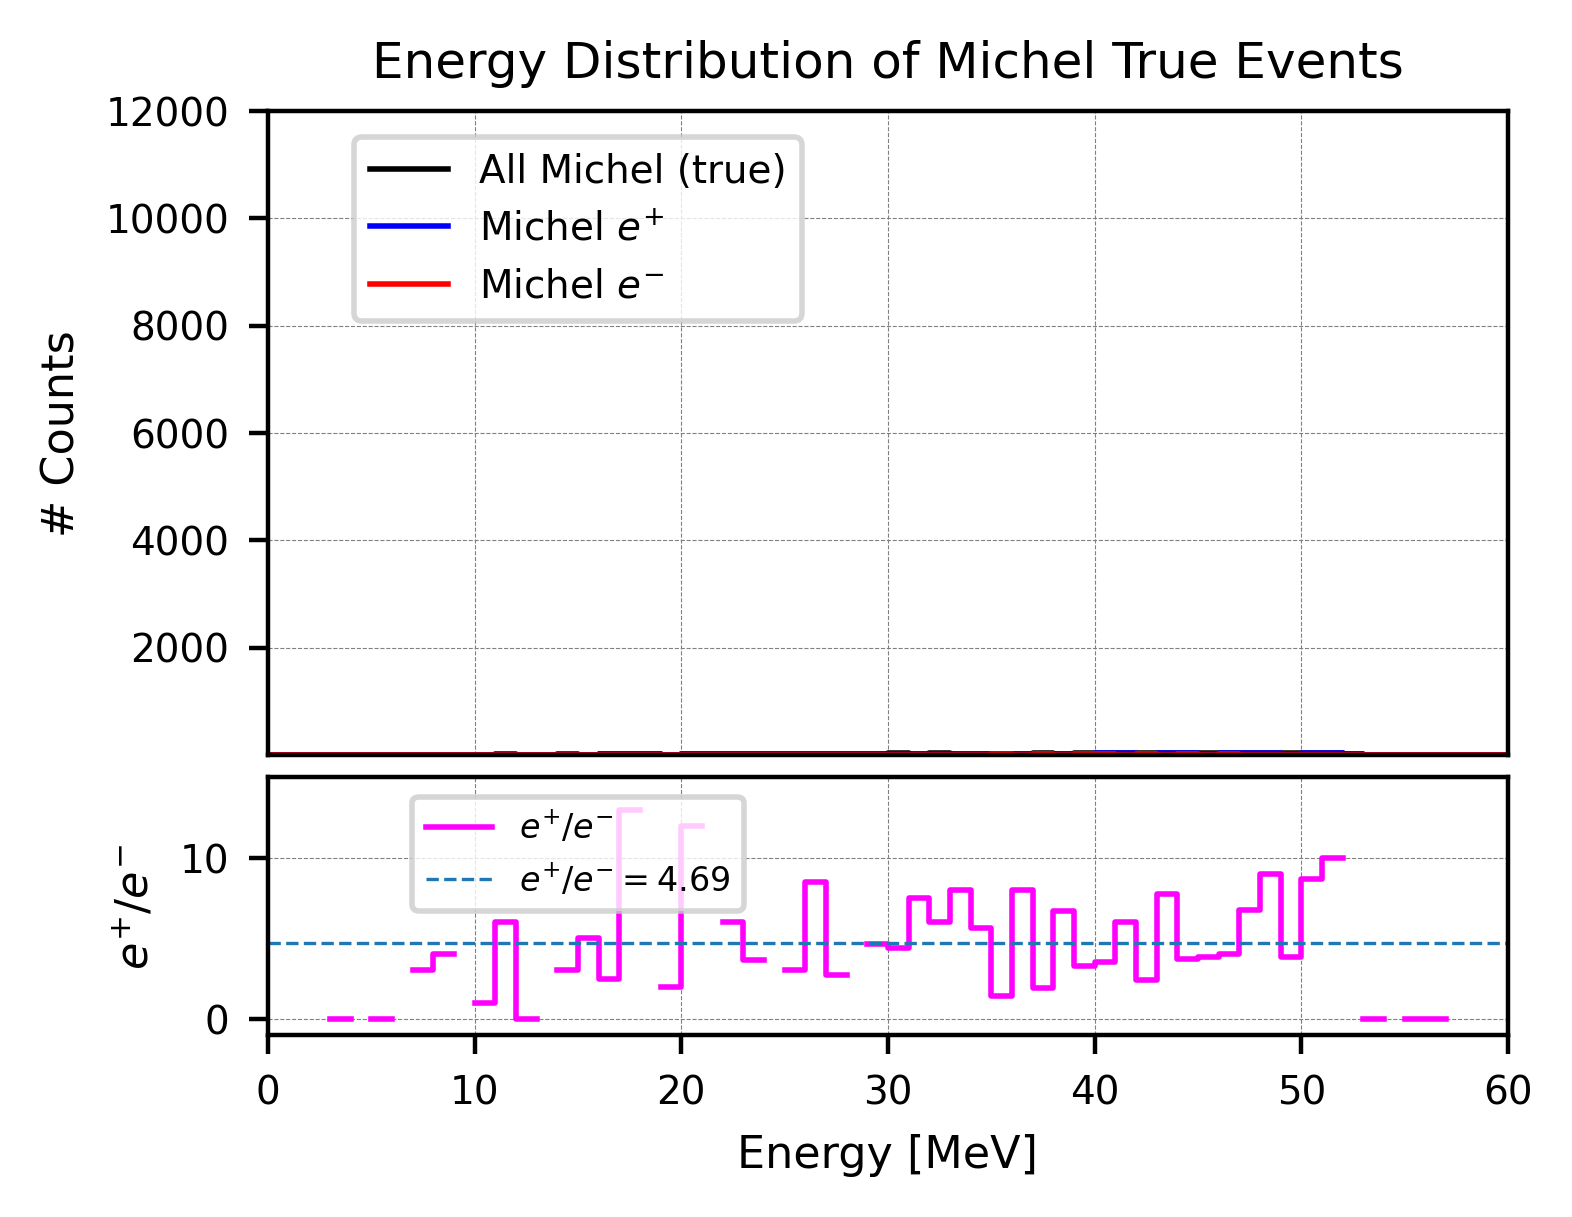

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -------------------------------------------------
# Prepare energy arrays
# -------------------------------------------------
vals_energy_total = np.array([ev.energy_initial for ev in events_true])
vals_energy_pM    = np.array([ev.energy_initial for ev in events_pM])
vals_energy_nM    = np.array([ev.energy_initial for ev in events_nM])

# -------------------------------------------------
# Binning
# -------------------------------------------------
bin_width = 1.0
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
nb = len(bin_centers)

# Counts (explicit)
h_tot, _ = np.histogram(vals_energy_total, bins=bins)
h_pM,  _ = np.histogram(vals_energy_pM,    bins=bins)
h_nM,  _ = np.histogram(vals_energy_nM,    bins=bins)

# Ratio: e+ / e- (skip bins where e- == 0)
ratio = np.full(nb, np.nan, dtype=float)
mask = h_nM > 0
ratio[mask] = h_pM[mask] / h_nM[mask]

# -------------------------------------------------
# Figure: GridSpec two panels (like your lifetime script)
# -------------------------------------------------
fig = plt.figure(figsize=(4, 3), dpi=400)
gs = GridSpec(2, 1, height_ratios=[5, 2], hspace=0.05)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# -------------------------------------------------
# Top panel: step histograms (use step() so it matches bins exactly)
# -------------------------------------------------
ax_top.step(bins[:-1], h_tot, where='post', color='black', linewidth=1.0, label='All Michel (true)')
ax_top.step(bins[:-1], h_pM,  where='post', color='blue', linewidth=1.0, label='Michel $e^{+}$')
ax_top.step(bins[:-1], h_nM,  where='post', color='red', linewidth=1.0, label='Michel $e^{-}$')

ax_top.set_xlim(0, 60)
ax_top.tick_params(labelbottom=False, bottom=False)
ax_top.set_ylim(0.9, 12000)
#ax_top.set_yscale('log')
ax_top.set_ylabel('# Counts', fontsize=8)
ax_top.tick_params(labelsize=7)
ax_top.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_top.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})
ax_top.set_title('Energy Distribution of Michel True Events', fontsize=9)



# -------------------------------------------------
# Bottom panel: ratio (step-mid to match histogram bins)
# -------------------------------------------------
ax_bot.plot(bin_centers, ratio, drawstyle='steps-mid', color='magenta', linewidth=1.0, label='$e^{+}/e^{-}$')
ax_bot.axhline(4.69, linestyle='--', linewidth=0.6, label='$e^{+}/e^{-} = 4.69$')

ax_bot.set_xlim(0, 60)
ax_bot.set_ylim(-1, 15)
ax_bot.set_xlabel('Energy [MeV]', fontsize=8)
ax_bot.set_ylabel('$e^{+}/e^{-}$', fontsize=8)
ax_bot.tick_params(labelsize=7)

ax_bot.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax_bot.legend(loc='upper center', bbox_to_anchor=(0.25, 0.99),
           fontsize=6, markerscale=4, ncol=1, prop={'size':6})


plt.show()


<br />
<br />
<br />
<br />

## True lifetime fitting:

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## TPC cuts:


### Apply cuts gradually:

In [7]:
initial_MS_reco = []#To be consistent with data---
Space_events_reco = []
MS_events_reco = []
MH_events_reco = [] # After Space & MS & MH cuts---

initial_MS_true = []
Space_events_true = []
MS_events_true = []
MH_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

    if 0.1 < MS:
        initial_MS_reco.append(ev)
        if E > 0:
            initial_MS_true.append(ev)

        #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
        if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    
            Space_events_reco.append(ev)
            if E > 0:
                Space_events_true.append(ev)

            if 0.5 < MS: #(Michel score cut)---
                MS_events_reco.append(ev)
                if E > 0:
                    MS_events_true.append(ev)
            
                if 8 < MH: #Michel hits cut---                
                    MH_events_reco.append(ev)
                    if E > 0:
                        MH_events_true.append(ev) 
                    
                    
                    

                    
#Initial size of dataset:-----
print("Reco events (initial): ", len(events_reco))
print("True events (initial): ", len(events_true), "({:.2f}%)".format(len(events_true)/len(events_reco)*100))

print("\nReco events (MS>0.1): ", len(initial_MS_reco))
print("True events (MS>0.1): ", len(initial_MS_true), "({:.2f}%)".format(len(initial_MS_true)/len(initial_MS_reco)*100))

print("\nReco events (Space cut): ", len(Space_events_reco), "({:.2f}%)".format(len(Space_events_reco)/len(events_reco)*100))
print("True events (Space cut): ", len(Space_events_true), "({:.2f}%)".format(len(Space_events_true)/len(Space_events_reco)*100))

print("\nReco events (Space & MS cuts): ", len(MS_events_reco), "({:.2f}%)".format(len(MS_events_reco)/len(events_reco)*100))
print("True events (Space & MS cuts): ", len(MS_events_true), "({:.2f}%)".format(len(MS_events_true)/len(MS_events_reco)*100))


print("\nReco events (Space & MS & MH cuts): ", len(MH_events_reco), "({:.2f}%)".format(len(MH_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(MH_events_true), "({:.2f}%)".format(len(MH_events_true)/len(MH_events_reco)*100))








Reco events (initial):  4252
True events (initial):  884 (20.79%)

Reco events (MS>0.1):  2049
True events (MS>0.1):  793 (38.70%)

Reco events (Space cut):  1121 (26.36%)
True events (Space cut):  708 (63.16%)

Reco events (Space & MS cuts):  607 (14.28%)
True events (Space & MS cuts):  542 (89.29%)

Reco events (Space & MS & MH cuts):  439 (10.32%)
True events (Space & MS & MH cuts):  413 (94.08%)



### Apply all cuts:

In [8]:

TPC_events_reco = [] # After Space & MS & MH cuts---

TPC_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    

        if 0.5 < MS: #(Michel score cut)---
            
            if 8 <MH: #Michel hits cut---                
                TPC_events_reco.append(ev)
                if E > 0:
                    TPC_events_true.append(ev) 



print("\nReco events (Space & MS & MH cuts): ", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(TPC_events_true), 
      "({:.2f}%)".format(len(TPC_events_true)/len(TPC_events_reco)*100))





Reco events (Space & MS & MH cuts):  439 (10.32%)
True events (Space & MS & MH cuts):  413 (94.08%)


Decay points distribution (After TPC cut): 
# of X < 0 :  169 (38.497%)
# of X >= 0:  270 (61.503%)

#decayX_TPC (total):  439
#decayX_apa1:  2 (0.46%)
#decayX_apa2:  167 (38.04%)
#decayX_apa3:  132 (30.07%)
#decayX_apa4:  138 (31.44%)


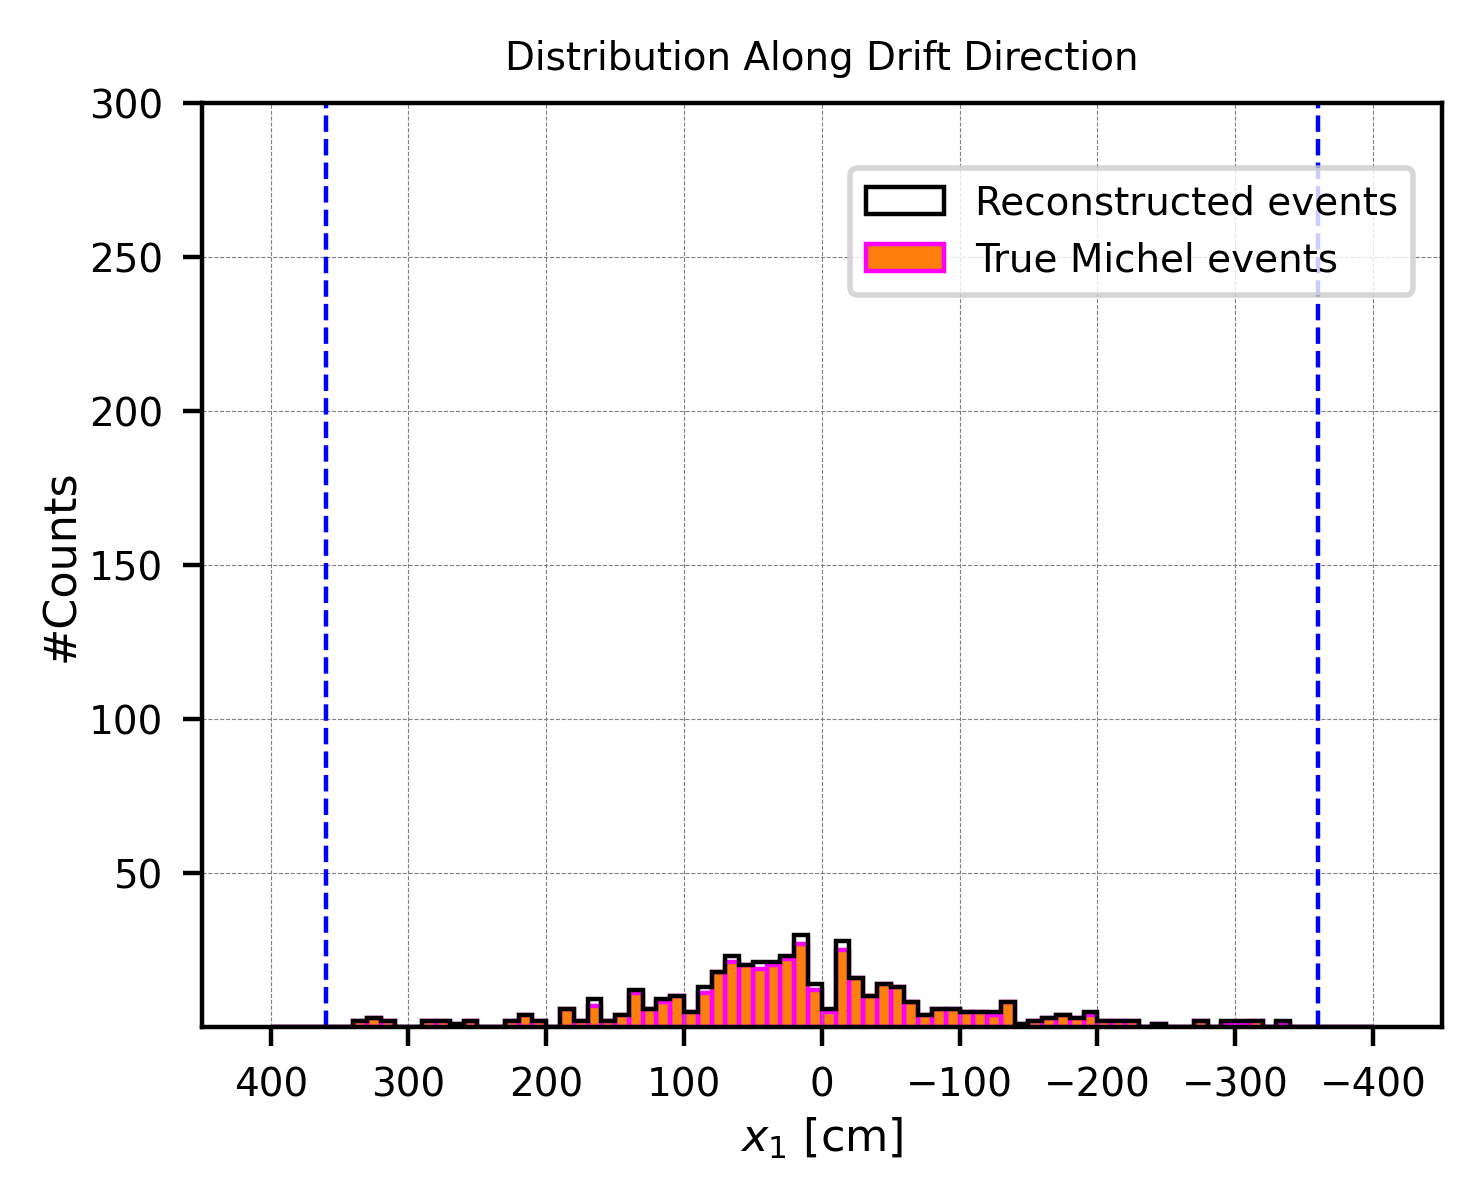

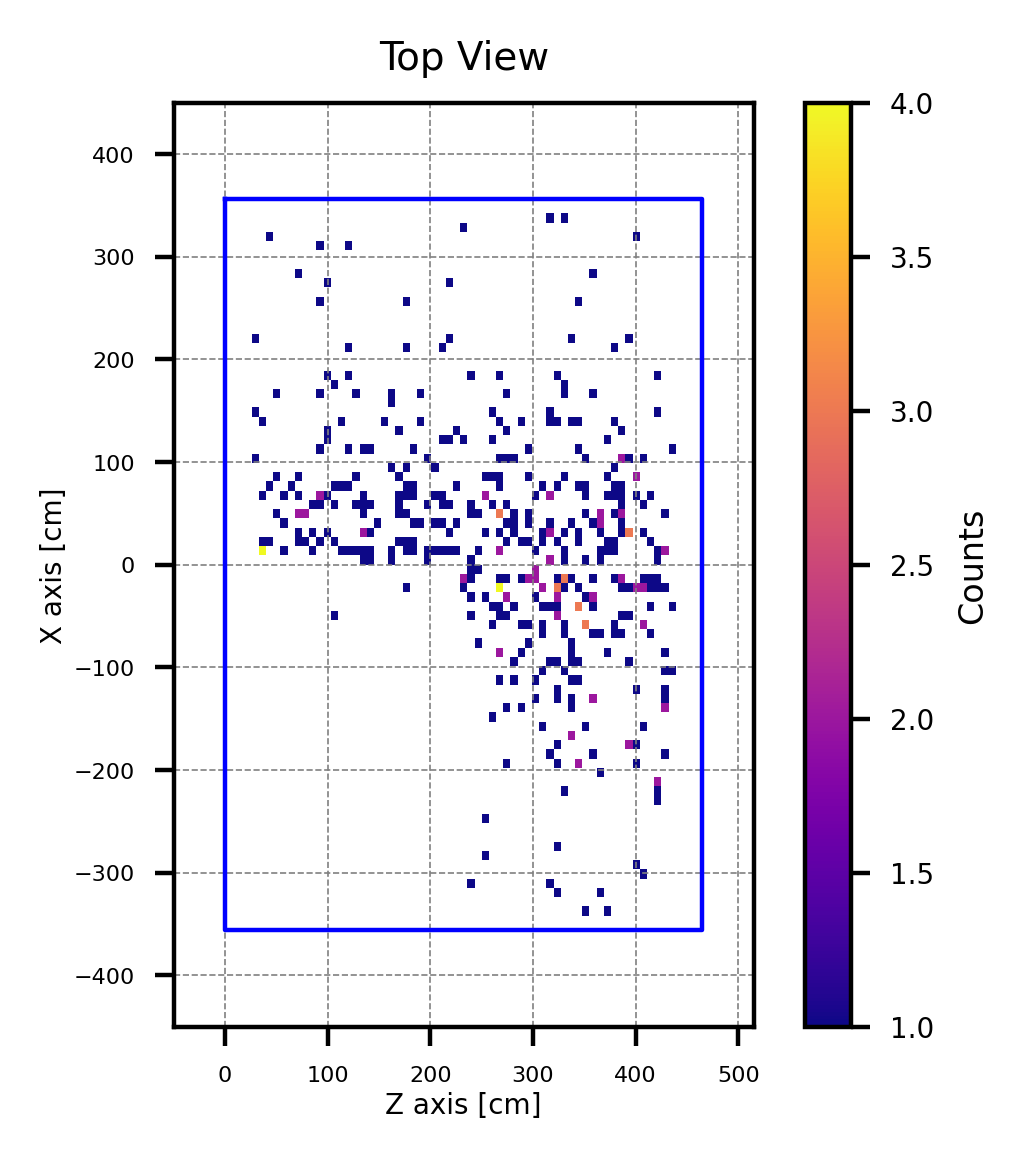

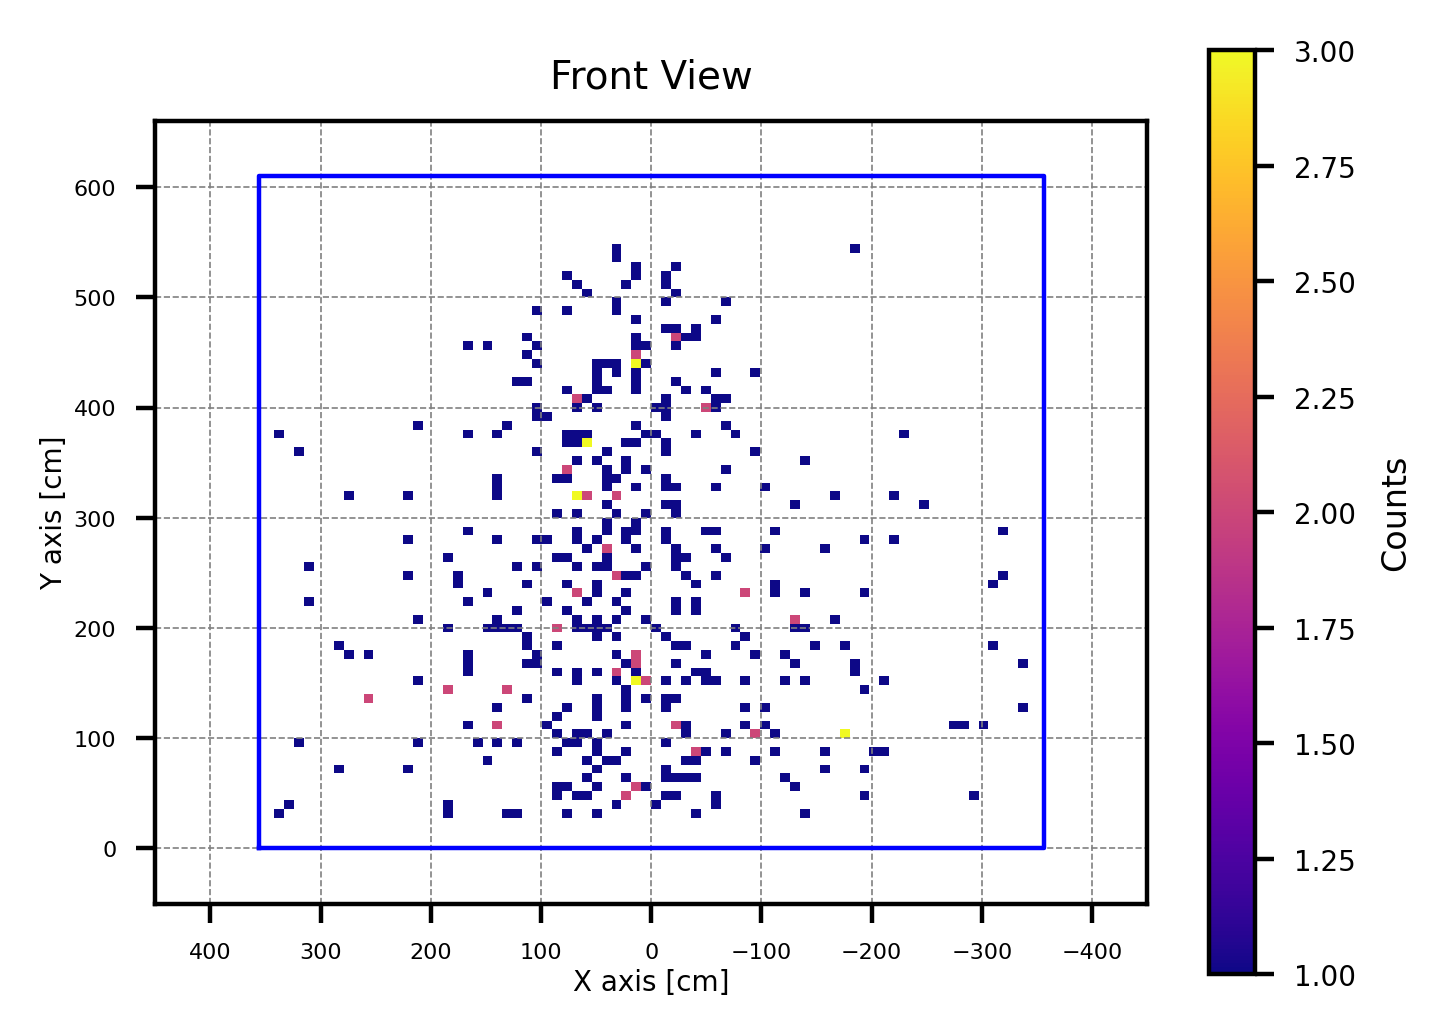

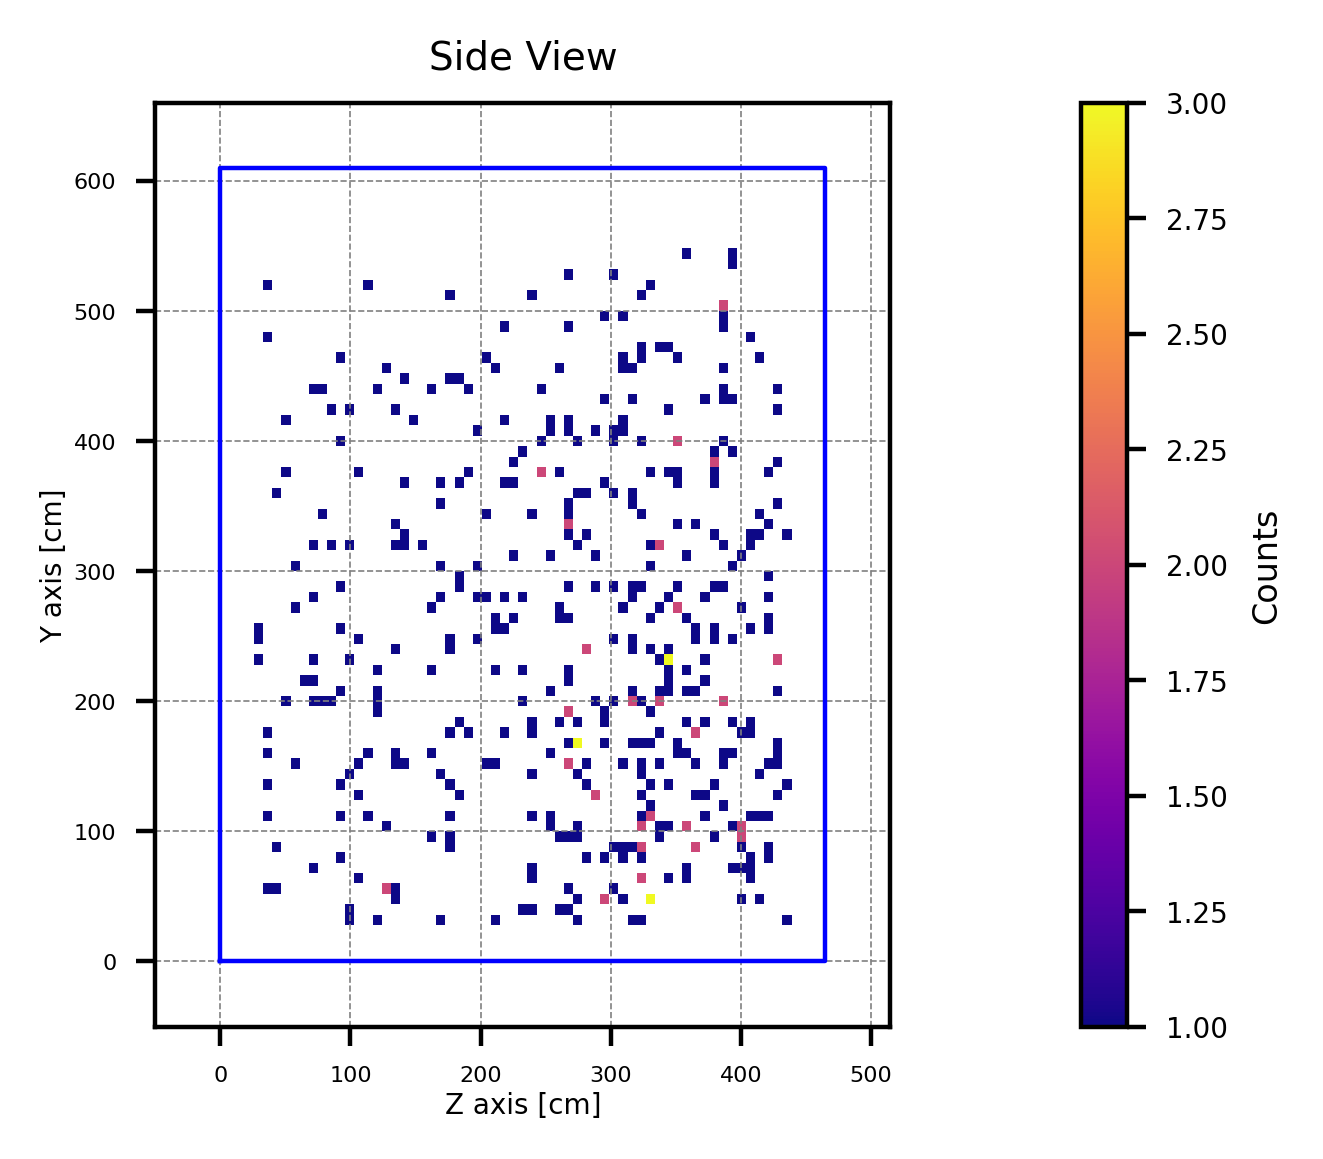

<Figure size 1600x1200 with 0 Axes>

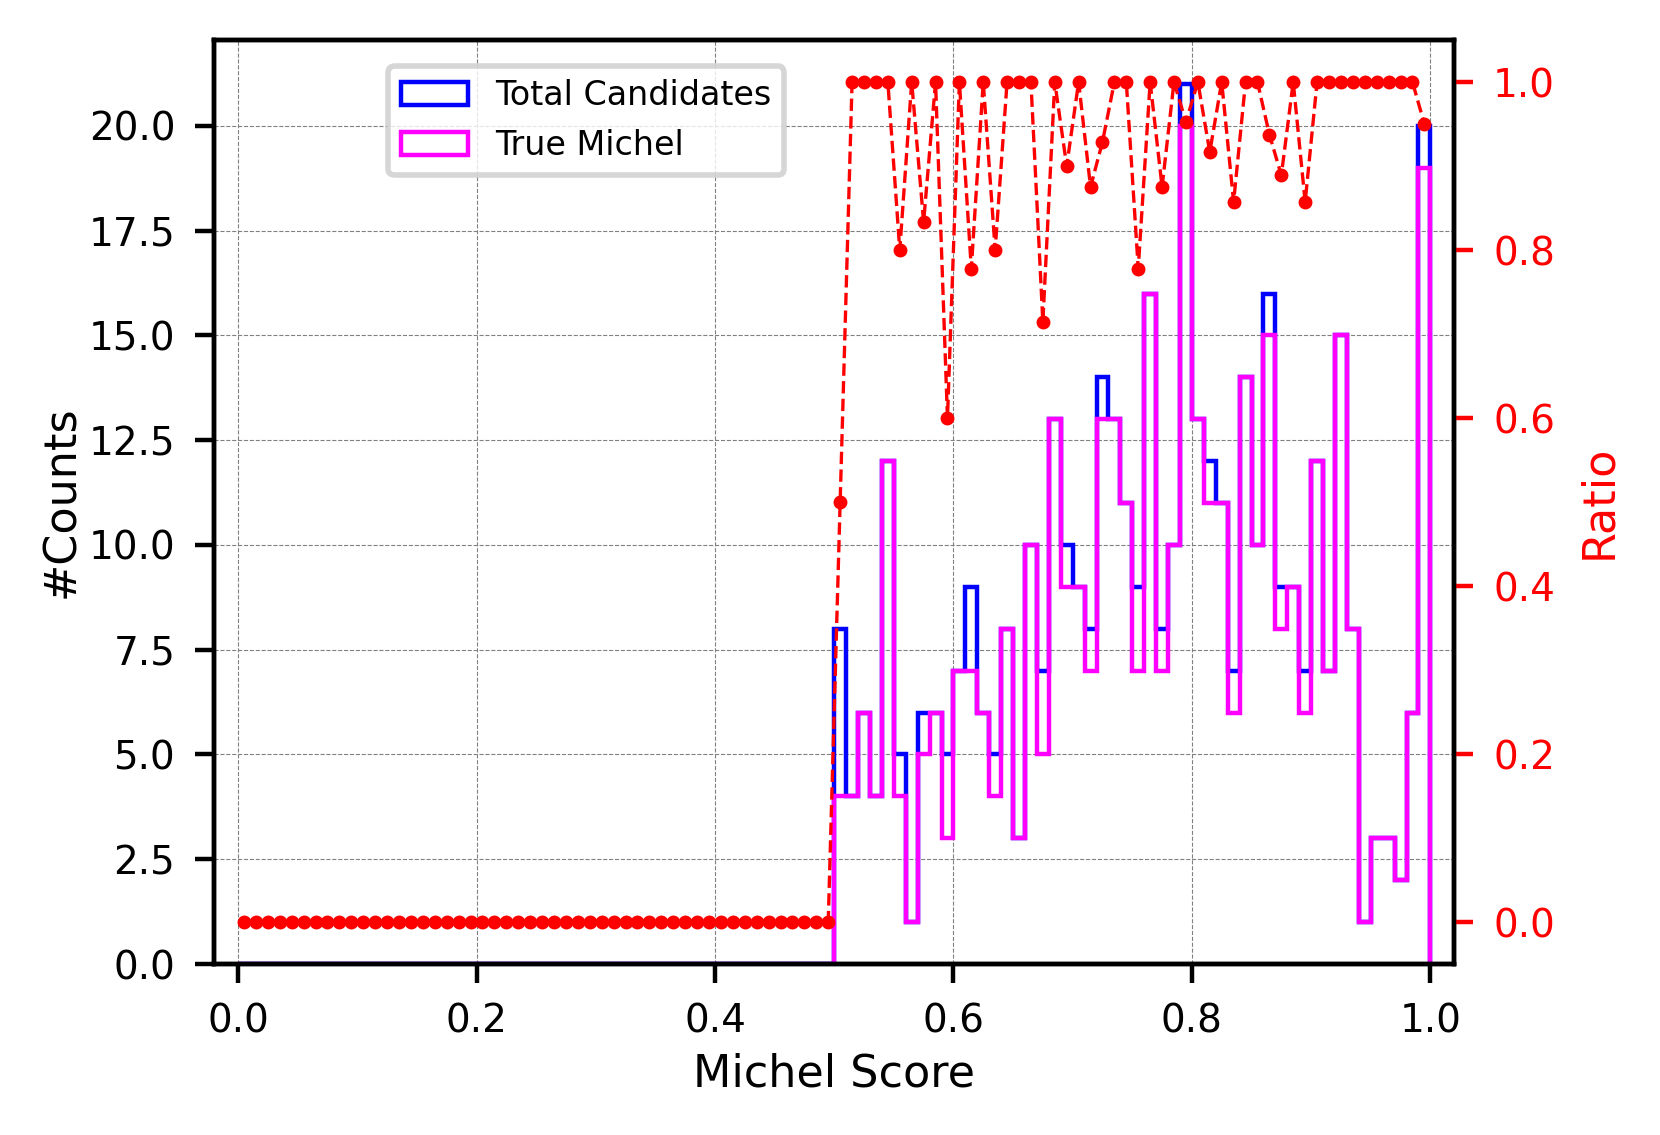

<Figure size 1600x1200 with 0 Axes>

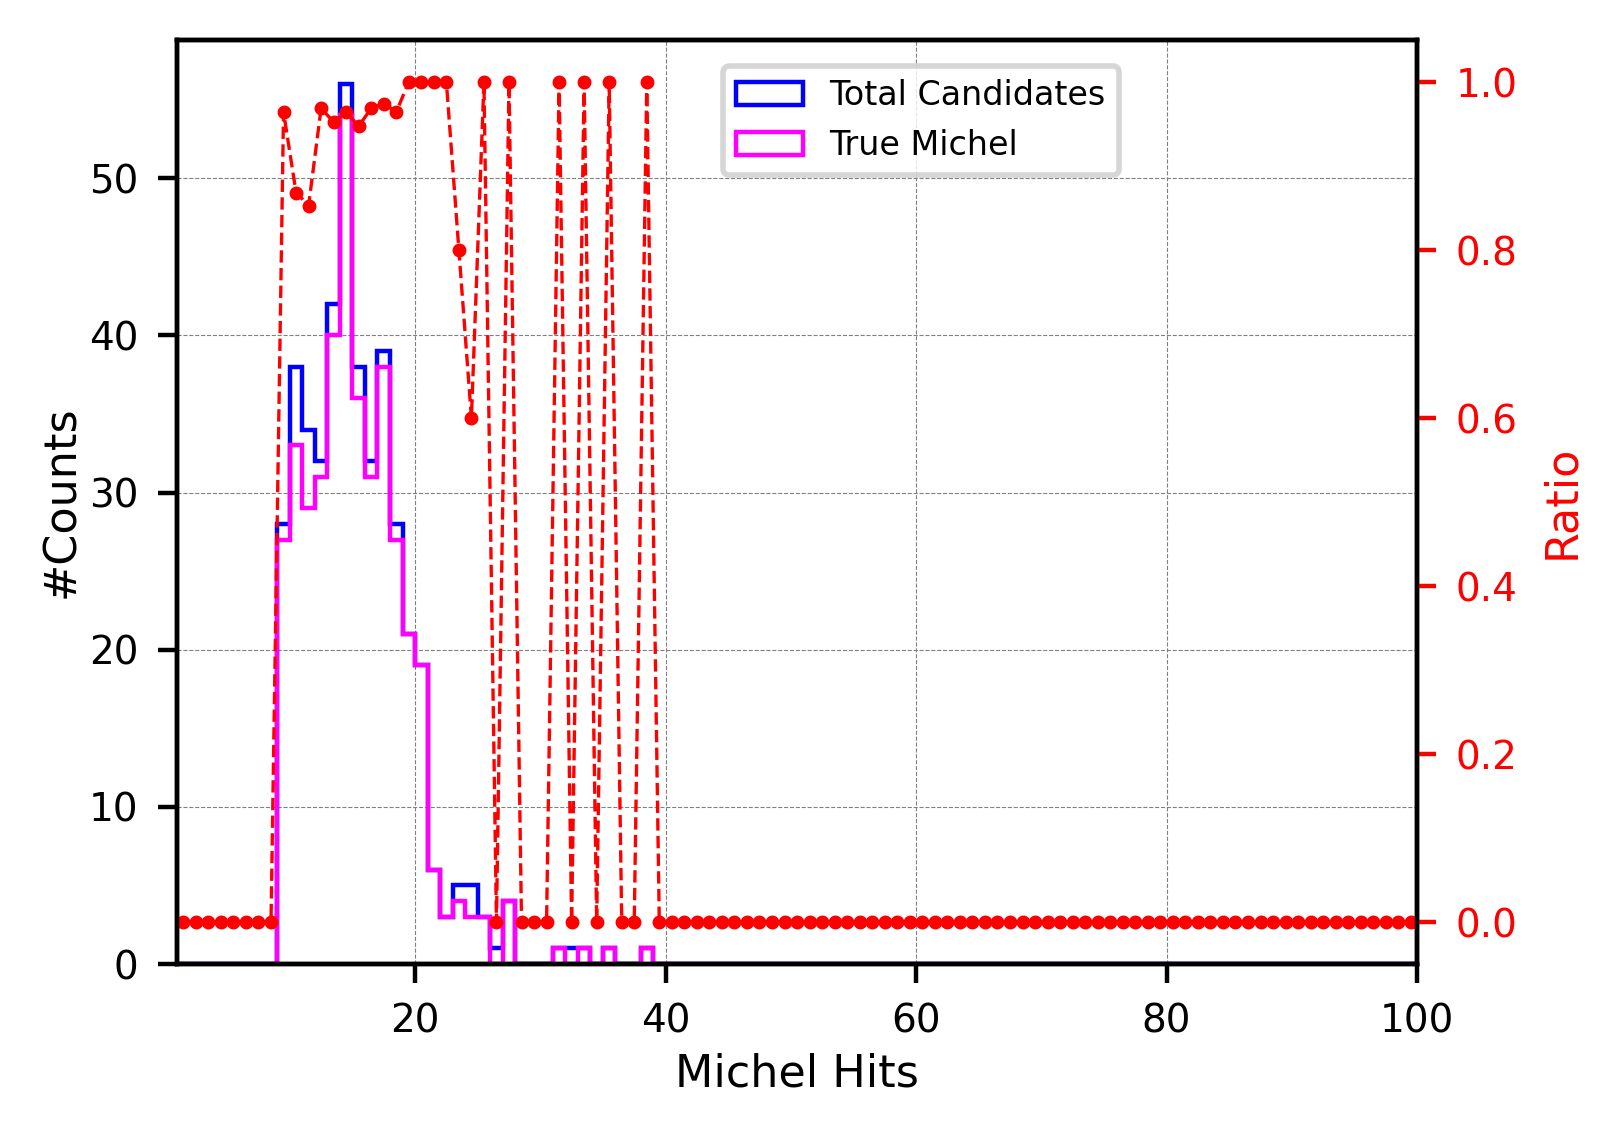




Starting points distribution: 


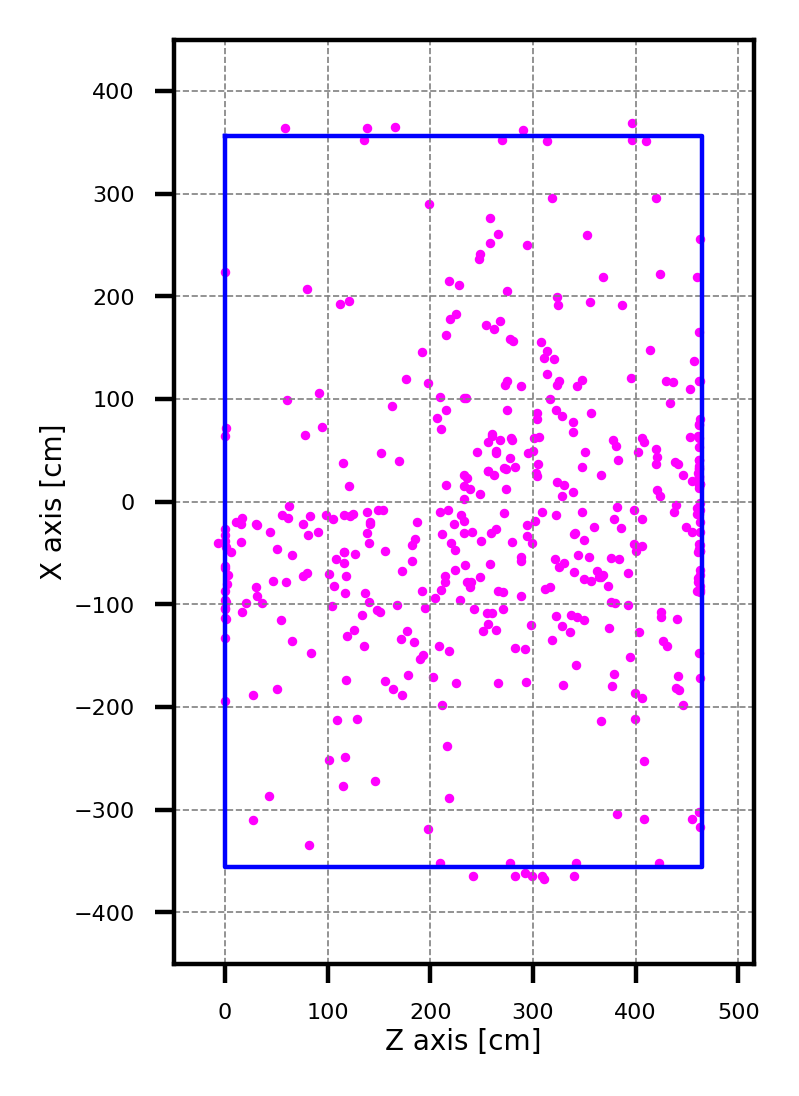

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



TPC_X = [ev.decayX_initial for ev in TPC_events_reco]
TPC_Y = [ev.decayY_initial for ev in TPC_events_reco]
TPC_Z = [ev.decayZ_initial for ev in TPC_events_reco]
TPC_MS = [ev.MS_initial for ev in TPC_events_reco]
TPC_MH = [ev.MH_initial for ev in TPC_events_reco]
TPC_startX = [ev.startX_initial for ev in TPC_events_reco]
TPC_startZ = [ev.startZ_initial for ev in TPC_events_reco]


TPC_X_true = [ev.decayX_initial for ev in TPC_events_true]
TPC_Y_true = [ev.decayY_initial for ev in TPC_events_true]
TPC_Z_true = [ev.decayZ_initial for ev in TPC_events_true]
TPC_MS_true = [ev.MS_initial for ev in TPC_events_true]
TPC_MH_true = [ev.MH_initial for ev in TPC_events_true]




#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

TPC_X = np.array(TPC_X)
neg_X = np.sum(TPC_X < 0)
pos_X = np.sum(TPC_X >= 0)
print("# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(TPC_X)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(TPC_X)*100))



#Decay points in 4 APA regions:==========================================
decayX_apa1 = []
decayX_apa2 = []
decayX_apa3 = []
decayX_apa4 = []

decayZ_apa1 = []
decayZ_apa2 = []
decayZ_apa3 = []
decayZ_apa4 = []

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        decayX_apa1.append(x)
        decayZ_apa1.append(z)              
    elif x <= 0 and z > 231.266: #APA2
        decayX_apa2.append(x)
        decayZ_apa2.append(z)        
    elif x > 0 and z <= 231.266: #APA3
        decayX_apa3.append(x)
        decayZ_apa3.append(z) 
    elif x > 0 and z > 231.266: #APA4
        decayX_apa4.append(x)
        decayZ_apa4.append(z) 


print("\n#decayX_TPC (total): ", len(TPC_X))
print("#decayX_apa1: ", len(decayX_apa1), "({:.2f}%)".format(len(decayX_apa1)/len(TPC_X)*100))
print("#decayX_apa2: ", len(decayX_apa2), "({:.2f}%)".format(len(decayX_apa2)/len(TPC_X)*100))
print("#decayX_apa3: ", len(decayX_apa3), "({:.2f}%)".format(len(decayX_apa3)/len(TPC_X)*100))
print("#decayX_apa4: ", len(decayX_apa4), "({:.2f}%)".format(len(decayX_apa4)/len(TPC_X)*100))








#Decay points distribution:==========================================



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 300], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 300], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(TPC_X_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_X, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_X, TPC_Y, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_Y, bins=(100, 100), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 









#Michel score distribution ----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MS, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02)
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show()









 

#Michel hits distribution -----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MH, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.6, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show() 








#Starting points distribution:==========================================
print("\n\n\nStarting points distribution: ")

#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(TPC_startZ, TPC_startX, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()



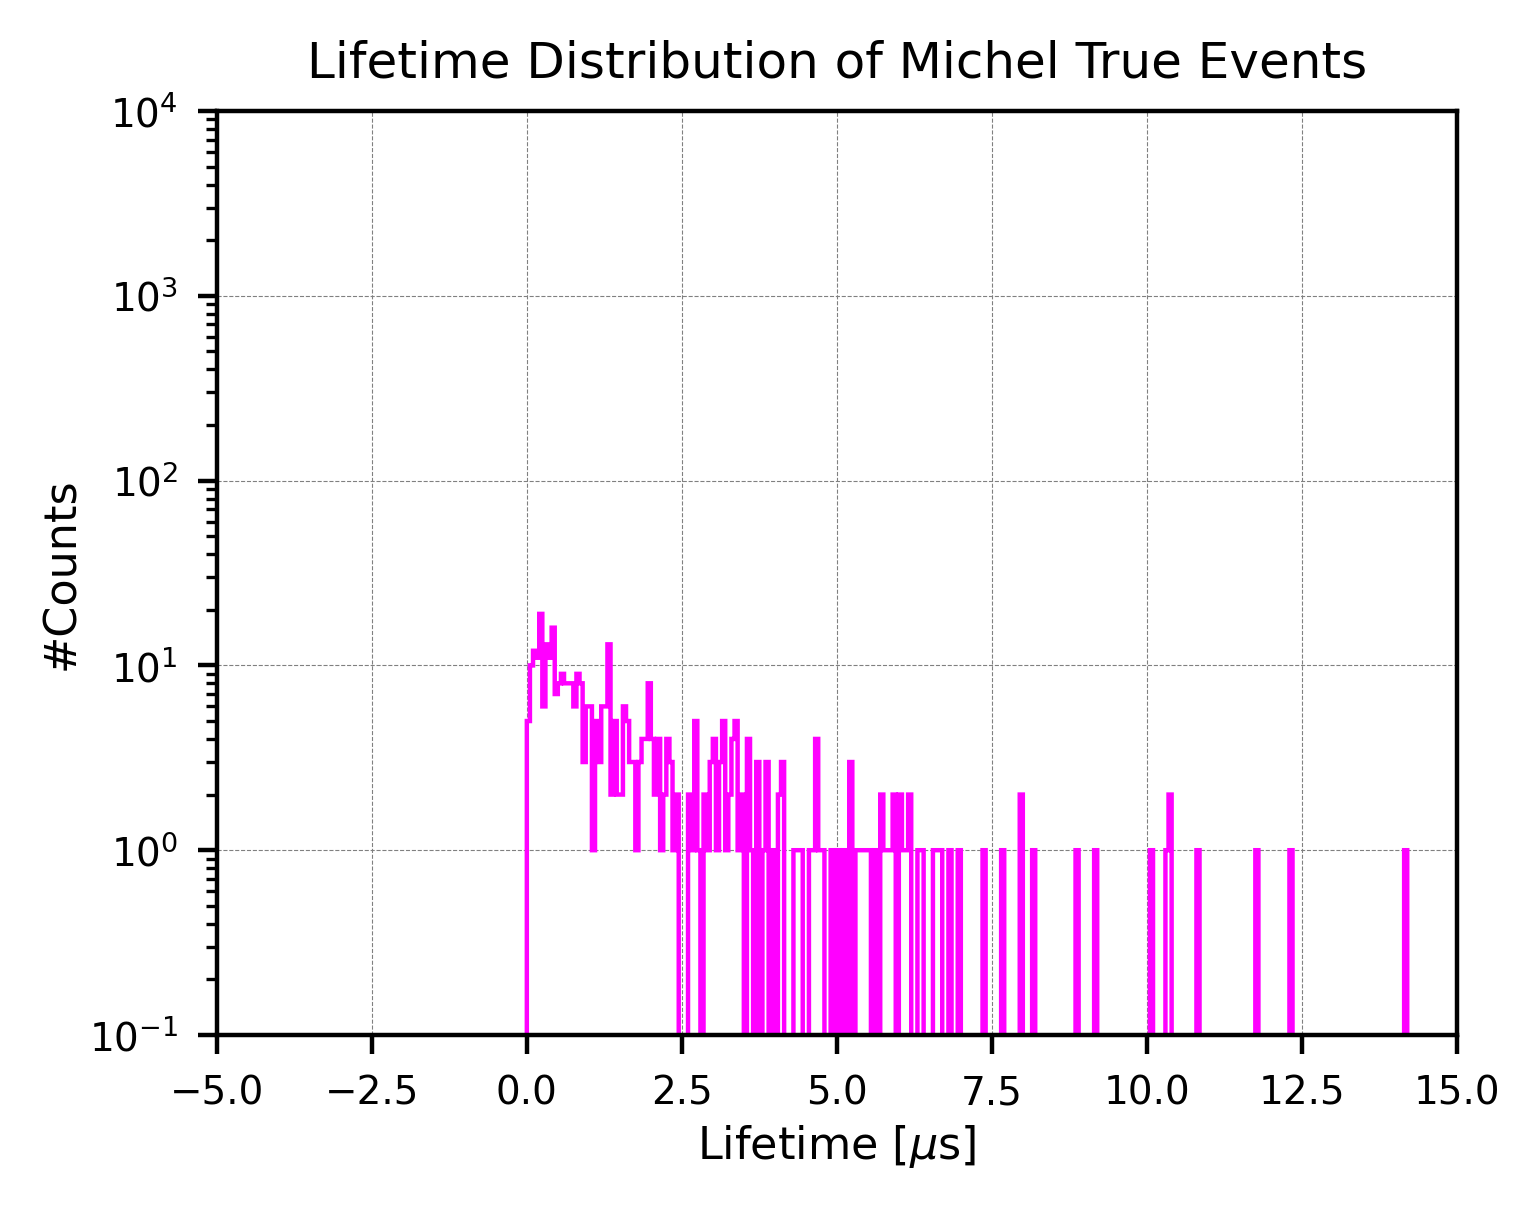

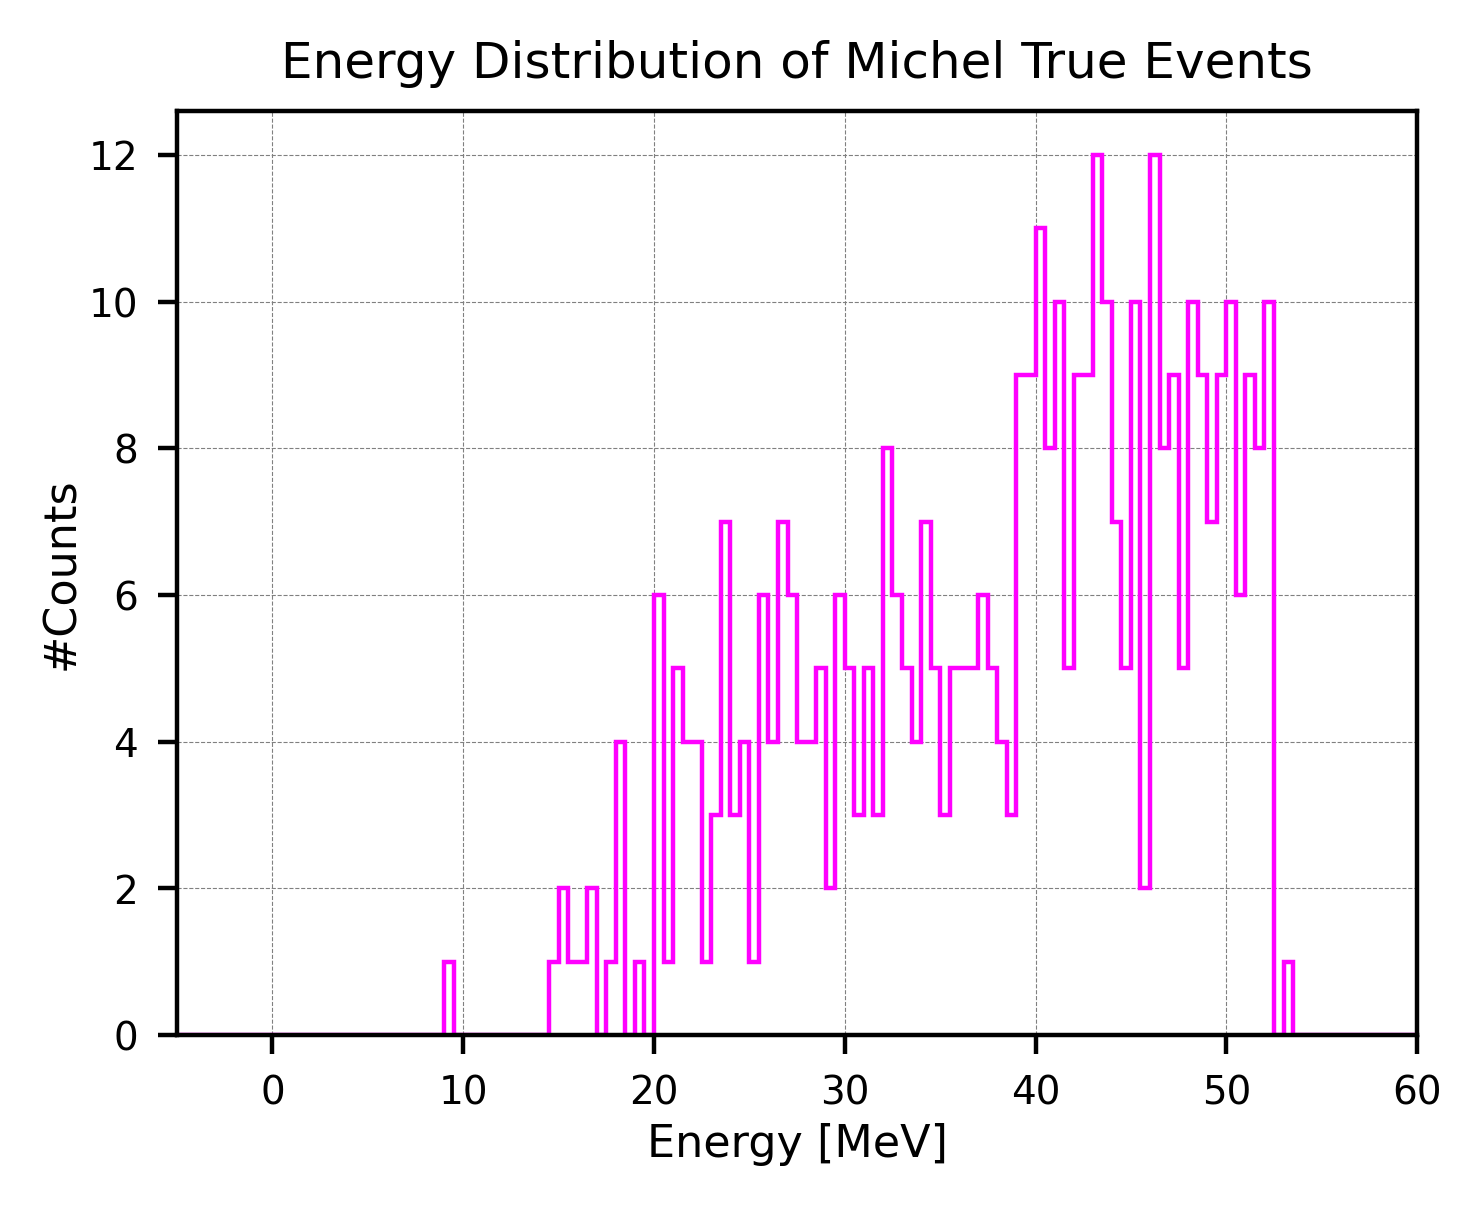

In [11]:

TPC_lifetime_true = [ev.lifetime_initial for ev in TPC_events_true]
TPC_energy_true = [ev.energy_initial for ev in TPC_events_true]


#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_lifetime_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 15)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 10000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()  










#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_energy_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 10000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  
